# **Single Cell Transcriptomics:Characterization of Cell Heterogeneity in Hepatocellular Carcinoma (HCC) and Intrahepatic Cholangiocarcinoma (iCCA)**


**A. Introduction**

This project presents a comprehensive single-cell RNA sequencing (scRNA-seq) analysis workflow focused on characterizing tumor-intrinsic states in human liver cancer, specifically Hepatocellular Carcinoma (HCC) and Intrahepatic Cholangiocarcinoma (iCCA). The analysis leverages data from the Cellxgene Census, a publicly available repository of single-cell transcriptomics data, and employs the `Scanpy` ecosystem for robust data processing, quality control, dimensionality reduction, clustering, and differential expression analysis.

The primary objective is to identify and delineate distinct malignant cell populations based on their transcriptional profiles, and to understand their distribution and characteristics across different liver cancer types.

**B. Scope and Limitations**


**Scope**

*   **Target Population:** Human liver cancer cells, specifically those classified as Hepatocellular Carcinoma (HCC) and Intrahepatic Cholangiocarcinoma (iCCA).
*   **Data Source:** Single-cell RNA-seq data from a selected dataset within the Cellxgene Census, focusing on liver tissue.
*   **Analytical Focus:** Identification of tumor-intrinsic cellular states, excluding the comprehensive analysis of tumor microenvironment immune or stromal components (though these are used for initial tumor cell filtering).
*   **Methodology:** Standardized `Scanpy` workflow for scRNA-seq preprocessing, dimensionality reduction, clustering, and differential expression analysis.






**Limitations**

*   **Dataset Specificity:** The analysis is based on a single dataset (`7b20c613-9add-43d1-87e9-defd3d9b9f8c`) from the Cellxgene Census. While chosen for its relevance, findings may not generalize universally across all liver cancer cohorts without further validation.
*   **Conservative Filtering:** Initial quality control thresholds are set conservatively, which might exclude certain rare but biologically relevant cell states if they fall outside typical quality metrics.
*   **Donor Effects:** While donor IDs are considered in visualizations, a full statistical deconvolution of donor-specific effects on tumor heterogeneity is not explicitly performed, which could be a confounder in some analyses.
*   **Manual Annotation:** The assignment of biological tumor states to computational clusters (`leiden`) is performed manually based on canonical marker gene expression. This process is inherently interpretive and reliant on existing biological knowledge and marker panels, and may require expert validation.
*   **Proliferative State:** The analysis noted that a proliferative tumor state appeared minor or absent in the selected dataset, indicating that this specific aspect of tumor biology might not be prominent or sufficiently captured in this data.

**C. Model Modules and Implementation**

The workflow systematically progresses through several key phases, integrating data acquisition, quality control, advanced bioinformatics analyses, and biological interpretation.

**1. Data Acquisition and Initial Filtering (Phase 2 & 3)**
*   **Data Source Interaction:** The `cellxgene_census` library was used to query and access single-cell data. The entire Census dataset metadata was loaded to identify relevant liver cancer studies.
*   **Dataset Identification:** Datasets containing keywords such as "liver," "hepat," "carcinoma," and "cancer" were shortlisted. A scoring mechanism was applied to prioritize datasets with specific disease labels (e.g., hepatocellular carcinoma, intrahepatic cholangiocarcinoma, normal).
*   **Target Dataset Selection:** A specific dataset (`DATASET_ID = "7b20c613-9add-43d1-87e9-defd3d9b9f8c"`) was selected, and liver-specific cells related to HCC and iCCA were extracted into an `AnnData` object, forming the basis for downstream analysis.




**2. Quality Control and Preprocessing (Phase 4)**
*   **Gene Symbol Normalization:** Gene names (`feature_name`) were assigned as `var_names`, and made unique to ensure consistency.
*   **Mitochondrial Gene Percentage Calculation:** `scanpy.pp.calculate_qc_metrics` was used to quantify mitochondrial gene expression, a common indicator of cell viability and quality.
*   **Cell and Gene Filtering:** Cells with fewer than 200 detected genes and genes expressed in fewer than 5 cells were removed. Cells with a high percentage of mitochondrial reads (greater than 25%) were also filtered out to remove low-quality cells.
*   **Normalization and Log-Transformation:** Raw counts were normalized to a total count of 10,000 per cell, followed by a log1p transformation to stabilize variance (`scanpy.pp.normalize_total`, `scanpy.pp.log1p`).
*   **Highly Variable Gene (HVG) Selection:** The top 3000 highly variable genes were identified (`scanpy.pp.highly_variable_genes`), which are crucial for capturing biological variation while reducing computational complexity.
*   **Dimensionality Reduction:** Principal Component Analysis (PCA) was performed to reduce the data to 50 principal components (`scanpy.tl.pca`).
*   **Graph-based Clustering:** A k-nearest neighbors graph was constructed (`scanpy.pp.neighbors`), and cells were partitioned into clusters using the Leiden algorithm (`scanpy.tl.leiden`).
*   **Visualization:** Uniform Manifold Approximation and Projection (UMAP) was used to visualize cell clusters and distributions in a 2D embedding space (`scanpy.tl.umap`).



**3. Cell Type Annotation and Tumor Cell Identification (Phase 5 & 7B)**
*   **Marker Gene Expression Analysis:** Canonical marker gene panels for various cell types (immune, stromal, hepatocyte-like, cholangiocyte-like) were used to validate and interpret `cell_type` annotations on UMAP.
*   **Programmatic Scoring:** Gene sets representing specific biological programs (e.g., T-cell exhaustion, Treg, myeloid inflammation, hepatocyte-like, cholangiocyte-like, and various non-tumor lineages) were scored using `scanpy.tl.score_genes` to quantify their activity in individual cells.
*   **Robust Tumor Cell Masking:** A composite score was created by summing hepatocyte-like and cholangiocyte-like scores (Tumor_lineage_score) and another by summing non-tumor cell scores (Non_tumor_score). Cells were identified as "tumor-like" if their Tumor_lineage_score was above the 70th percentile and their Non_tumor_score was below the 70th percentile, creating a conservative filter for malignant cells.
*   **Tumor-only AnnData Object:** A new AnnData object (`adata_tum`) was created, containing only the cells identified as tumor-like.



**4. Refined Tumor Subsetting and Re-embedding (Phase 7B & 7C)**
*   **Exclusion of Suspect Clusters:** Differentially expressed genes for each cluster within the `adata_tum` were analyzed. Clusters significantly enriched for immune or stromal markers (defined by a `HIT_THRESHOLD` of 2 or more suspect marker hits) were identified and removed, further purifying the tumor cell population. This created `adata_tum_pure`.
*   **Re-embedding for Tumor Heterogeneity:** The preprocessing pipeline (normalization, HVG selection, PCA, neighbors, Leiden, UMAP) was re-applied specifically to the purified `adata_tum` to maximize the resolution of tumor-intrinsic heterogeneity. This allows for a finer-grained clustering and visualization of tumor cell states.




**5. Differential Expression (DE) Analysis (Phase 7D)**
*   **Tumor State Marker Identification:** Differential expression analysis was performed between each `tumor_leiden` cluster and all other tumor cells to identify unique marker genes for each state using the Wilcoxon rank-sum test (`scanpy.tl.rank_genes_groups`).
*   **Disease-Specific DE:** DE analysis was also conducted to compare gene expression profiles between Hepatocellular Carcinoma (HCC) and Intrahepatic Cholangiocarcinoma (iCCA) cells within the tumor compartment, revealing disease-specific molecular signatures.



**6. Tumor State Assignment and Validation (Phase 8)**
*   **Manual Cluster Annotation:** Based on the DE results and established canonical marker genes, `tumor_leiden` clusters were manually assigned to five predefined tumor-intrinsic states: Differentiated Hepatocyte-like (Hep-Diff), Differentiated Cholangiocyte-like (Chol-Diff), Stress/Inflammatory, EMT/Mesenchymal, and Proliferative (if present).
*   **Quantitative Composition Analysis:** The proportional representation of each assigned `tumor_state` across disease types (HCC vs. iCCA) was quantified to understand disease-specific tumor state enrichment.
*   **Program Score Correlation:** The average expression of biological program scores (e.g., Hep_like, Chol_like) was calculated for each `tumor_state` to validate their molecular characteristics.
*   **Visual Confirmation (DotPlot & UMAP):** DotPlots were generated to visually confirm the expression patterns of canonical marker genes across the assigned `tumor_state` labels. UMAP visualizations were used to inspect the spatial distribution of these states and disease labels in the embedding space.
*   **Iterative Refinement:** The `tumor_state` assignments were refined and corrected based on the visual validation with DotPlots, demonstrating an iterative approach to biological interpretation.

# **Phase 0.2 — Stabilize the runtime**

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# Optional: pin to a single GPU for stability
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print("Pinned CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])


Pinned CUDA_VISIBLE_DEVICES = 0


# **Phase 1A — Install only the Census + Scanpy stack (kernel-safe)**

In [ ]:
!pip -q install --upgrade \
  "cellxgene-census>=1.0" "tiledbsoma>=1.8" "pyarrow>=12" \
  "anndata>=0.10" "scanpy>=1.10" "pandas>=2.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.2/174.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 

In [ ]:
import scanpy as sc, anndata as ad, pandas as pd
import cellxgene_census, tiledbsoma
print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("cellxgene_census:", cellxgene_census.__version__)
print("tiledbsoma:", tiledbsoma.__version__)


scanpy: 1.11.5
anndata: 0.12.7
cellxgene_census: 1.17.0
tiledbsoma: 2.2.0


/tmp/ipython-input-3862767799.py:3: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)
/tmp/ipython-input-3862767799.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata:", ad.__version__)


# **Phase 2 — Discover “human liver cancer” datasets in Census**

In [ ]:
import cellxgene_census
import pandas as pd

census = cellxgene_census.open_soma(census_version="stable")
datasets = census["census_info"]["datasets"].read().concat().to_pandas()
print("Total datasets:", len(datasets))
display(datasets.head())


The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Total datasets: 1845


,soma_joinid,citation,collection_id,collection_name,collection_doi,collection_doi_label,dataset_id,dataset_version_id,dataset_title,dataset_h5ad_path,dataset_total_cell_count
0,0,Publication: https://doi.org/10.1016/j.isci.20...,8e880741-bf9a-4c8e-9227-934204631d2a,High Resolution Slide-seqV2 Spatial Transcript...,10.1016/j.isci.2022.104097,Marshall et al. (2022) iScience,4eb29386-de81-452f-b3c0-e00844e8c7fd,66699060-0389-4fbd-b3a5-196b3b4e32d6,Spatial transcriptomics in mouse: Puck_191112_05,4eb29386-de81-452f-b3c0-e00844e8c7fd.h5ad,10888
1,1,Publication: https://doi.org/10.1016/j.isci.20...,8e880741-bf9a-4c8e-9227-934204631d2a,High Resolution Slide-seqV2 Spatial Transcript...,10.1016/j.isci.2022.104097,Marshall et al. (2022) iScience,78d59e4a-82eb-4a61-a1dc-da974d7ea54b,f64950a2-a3c8-490a-8431-7121eeb4f5f4,Spatial transcriptomics in mouse: Puck_191112_08,78d59e4a-82eb-4a61-a1dc-da974d7ea54b.h5ad,10250
2,2,Publication: https://doi.org/10.1016/j.isci.20...,8e880741-bf9a-4c8e-9227-934204631d2a,High Resolution Slide-seqV2 Spatial Transcript...,10.1016/j.isci.2022.104097,Marshall et al. (2022) iScience,add5eb84-5fc9-4f01-982e-a346dd42ee82,781a724a-b0f5-46c4-9a13-e6293ef4364f,Spatial transcriptomics in mouse: Puck_191109_20,add5eb84-5fc9-4f01-982e-a346dd42ee82.h5ad,12906
3,3,Publication: https://doi.org/10.1016/j.isci.20...,8e880741-bf9a-4c8e-9227-934204631d2a,High Resolution Slide-seqV2 Spatial Transcript...,10.1016/j.isci.2022.104097,Marshall et al. (2022) iScience,b020294c-ab82-4547-b5a7-63d8ffa575ed,96a79598-297b-4ade-a6c1-a431ab243548,Spatial transcriptomics in mouse: Puck_191112_13,b020294c-ab82-4547-b5a7-63d8ffa575ed.h5ad,15161
4,4,Publication: https://doi.org/10.1038/s41591-02...,a96133de-e951-4e2d-ace6-59db8b3bfb1d,HTAN/HTAPP Broad - Spatio-molecular dissection...,10.1038/s41591-024-03215-z,Klughammer et al. (2024) Nat Med,d7476ae2-e320-4703-8304-da5c42627e71,ac9fe945-6784-48fa-a2d5-a8646196d37e,HTAPP-330-SMP-1082 scRNA-seq,d7476ae2-e320-4703-8304-da5c42627e71.h5ad,565


In [ ]:
def contains_any(s, keywords):
    if pd.isna(s):
        return False
    s = str(s).lower()
    return any(k in s for k in keywords)

kw = ["liver", "hepat", "hcc", "hepatocellular", "cholangi", "carcinoma", "tumor", "cancer"]

text_cols = [c for c in ["dataset_title","dataset_description","collection_name","collection_description"] if c in datasets.columns]

cand = datasets[datasets.apply(
    lambda row: any(contains_any(row.get(col, ""), kw) for col in text_cols),
    axis=1
)].copy()

cand["text_blob"] = cand[text_cols].astype(str).agg(" ".join, axis=1).str.lower()
boost = ["hepatocellular", "hcc", "tumor microenvironment", "carcinoma", "cholangi"]
cand["score"] = cand["text_blob"].apply(lambda s: sum(1 for b in boost if b in s))

cols = [c for c in ["dataset_id","dataset_title","collection_name","dataset_description"] if c in cand.columns]
cand_sorted = cand.sort_values("score", ascending=False)

print("Candidate datasets:", len(cand_sorted))
display(cand_sorted[cols + ["score"]].head(15))


Candidate datasets: 261


,dataset_id,dataset_title,collection_name,score
136,6d243918-f3f6-4a9e-b72e-39d96de73095,"Renal cell carcinoma, post aPD1, lung metastas...",Spatially mapping T cell receptors and transcr...,1
1635,b617ee1b-f8c8-4de9-b82b-e803ab93550d,A multi-tissue single-cell tumor microenvironm...,Dissecting novel myeloid-derived cell states t...,1
109,cc43509e-8729-4cbc-ace9-f0f7d654ee53,"Renal cell carcinoma, post aPD1, lung metastas...",Spatially mapping T cell receptors and transcr...,1
1732,afae4675-434d-4e89-b5ce-2854c9dc38a3,snRNA-seq of all cells in high-risk Neuroblast...,HTAN CHOP - Longitudinal single-cell multiomic...,1
1651,232e432a-cef1-4654-8850-3c80244c1a0c,snRNA-seq of neoplastic cells in high-risk Neu...,HTAN CHOP - Longitudinal single-cell multiomic...,1
5,0895c838-e550-48a3-a777-dbcd35d30272,Healthy human liver: B cells,"Single-Cell, Single-Nucleus, and Spatial RNA S...",1
216,32ffc3a7-c88d-49e1-894f-8e09d0184ee9,"Renal cell carcinoma, post aPD1, lung metastas...",Spatially mapping T cell receptors and transcr...,1
213,9f049476-2431-4645-a2d6-f6e85892b603,Healthy human liver: cholangiocytes,"Single-Cell, Single-Nucleus, and Spatial RNA S...",1
1445,02792605-4760-4023-82ad-40fc4458a5db,All cells types from scRNA-seq of human primar...,Single-cell and spatial transcriptomics charac...,1
1416,e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,BCC and Normal - scRNA-seq data,Multi-scale spatial mapping of cell population...,1


# **Phase 2.5 — refine candidates**

In [ ]:
print(list(census.keys()))


['census_data', 'census_info', 'census_spatial_sequencing']


# Phase 2.5B.1 — Inspect human (homo_sapiens) obs schema correctly

In [ ]:
print(list(census["census_data"].keys()))


['callithrix_jacchus', 'homo_sapiens', 'macaca_mulatta', 'mus_musculus', 'pan_troglodytes']


# Phase 2.5B.2 — Inspect human (homo_sapiens) obs schema correctly 2.5B.2 — Listing what is inside the human group

In [ ]:
human = census["census_data"]["homo_sapiens"]
print(list(human.keys()))


['ms', 'obs']


# Phase 2.5B.3 — Now inspect obs columns

In [ ]:
obs_cols = human["obs"].schema.names
print("Available obs columns (first 60):")
print(obs_cols[:60])
print("Total obs columns:", len(obs_cols))


Available obs columns (first 60):
['soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars']
Total obs columns: 28


# Phase 2.5C — Pull liver-specific metadata and discover disease labels

Once obs_cols works, run:

Phase 2.5C.1 — Check unique tissues containing “liver” (to confirm spelling)

In [ ]:
import pandas as pd

# Read only the 'tissue' column to keep it light
tissues = human["obs"].read(column_names=["tissue"]).concat().to_pandas()
u = pd.Series(tissues["tissue"].unique()).dropna().sort_values()
display(u[u.str.contains("liver", case=False, na=False)].head(50))
print("Total unique tissues:", len(u))


,0
1,caudate lobe of liver
347,left lobe of liver
0,liver
321,right lobe of liver


Total unique tissues: 417


# Phase 2.5C.2 — Fetch disease labels for liver cells only (light columns)

In [ ]:
cols = [c for c in ["tissue", "disease", "dataset_id"] if c in obs_cols]
liver_obs = human["obs"].read(
    value_filter="tissue == 'liver'",
    column_names=cols
).concat().to_pandas()

print("Rows (liver cells):", len(liver_obs))
display(pd.Series(liver_obs["disease"].unique()).dropna().sort_values().head(50))


Rows (liver cells): 2309746


,0
8,blastoma
0,breast cancer
1,colorectal cancer
7,colorectal carcinoma || metastatic malignant n...
11,hepatocellular carcinoma
9,intestinal failure–associated liver disease
12,intrahepatic cholangiocarcinoma
10,liver cancer
6,lung adenocarcinoma
4,malignant ovarian serous tumor


# **Phase 2.6 — Identify the best dataset(s) for HCC and pull quality proxies**

Standards require: human, liver, cancer label, adequate size, good metadata, and ideally tumor + non-tumor.


# Phase 2.6.1 — Count cells by dataset for HCC and iCCA


Generate a ranked table of the datasets that actually contain liver + HCC (and optionally iCCA)

In [ ]:
import pandas as pd

# Keep it light: only what we need
cols = ["dataset_id", "disease"]
df = liver_obs[cols].copy()

# Focus diseases of interest
target_diseases = ["hepatocellular carcinoma", "intrahepatic cholangiocarcinoma", "liver cancer", "normal"]
df = df[df["disease"].isin(target_diseases)]

# Count cells
counts = (
    df.groupby(["dataset_id", "disease"])
      .size()
      .reset_index(name="n_cells")
      .sort_values(["disease", "n_cells"], ascending=[True, False])
)

display(counts.head(50))
print("Unique datasets in filtered set:", counts["dataset_id"].nunique())


/tmp/ipython-input-86686893.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["dataset_id", "disease"])


,dataset_id,disease,n_cells
0,0041b9c3-6a49-4bf7-8514-9bc7190067a7,Alzheimer disease,0
259,00476f9f-ebc1-4b72-b541-32f912ce36ea,Alzheimer disease,0
518,00593d17-0693-4646-acad-89dbefba11bb,Alzheimer disease,0
777,0087cde2-967d-4f7c-8e6e-40e4c9ad1891,Alzheimer disease,0
1036,00e5dedd-b9b7-43be-8c28-b0e5c6414a62,Alzheimer disease,0
1295,00f15b43-f871-46d8-8105-814387ad8658,Alzheimer disease,0
1554,00ff600e-6e2e-4d76-846f-0eec4f0ae417,Alzheimer disease,0
1813,01209dce-3575-4bed-b1df-129f57fbc031,Alzheimer disease,0
2072,0129dbd9-a7d3-4f6b-96b9-1da155a93748,Alzheimer disease,0
2331,015c230d-650c-4527-870d-8a805849a382,Alzheimer disease,0


Unique datasets in filtered set: 1086


# **Phase 2.7 — Add “paired control” signal (tumor vs normal availability)**

A high-quality first dataset usually has:

- HCC tumor cells and..

- normal liver in the same dataset_id (or at least in the same collection)

# Phase  2.7.1 — Find dataset_ids that include both HCC and normal liver

In [ ]:
pivot = counts.pivot_table(
    index="dataset_id",
    columns="disease",
    values="n_cells",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Add a simple selection score
pivot["has_HCC"] = pivot.get("hepatocellular carcinoma", 0) > 0
pivot["has_normal"] = pivot.get("normal", 0) > 0
pivot["has_iCCA"] = pivot.get("intrahepatic cholangiocarcinoma", 0) > 0

# Prefer HCC + normal; then large HCC
pivot["priority_score"] = (
    pivot["has_HCC"].astype(int) * 100 +
    pivot["has_normal"].astype(int) * 50 +
    pivot.get("hepatocellular carcinoma", 0) / 10000
)

pivot_sorted = pivot.sort_values("priority_score", ascending=False)
display(pivot_sorted.head(30))


/tmp/ipython-input-2747253465.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = counts.pivot_table(


disease,dataset_id,Alzheimer disease,B-cell acute lymphoblastic leukemia,B-cell non-Hodgkin lymphoma,Barrett esophagus,COVID-19,Crohn disease,Down syndrome,HER2 positive breast carcinoma,HIV infectious disease,...,uveal melanoma,vascular dementia,vascular dementia || Lewy body dementia,vascular dementia || diabetes mellitus,vascular dementia || diabetes mellitus || Parkinson disease,vascular dementia || progressive supranuclear palsy,has_HCC,has_normal,has_iCCA,priority_score
520,7b20c613-9add-43d1-87e9-defd3d9b9f8c,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,True,False,True,100.3252
396,5a11f879-d1ef-458a-910c-9b0bdfca5ebf,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
131,1b9d8702-5af8-4142-85ed-020eb06ec4f6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
1080,fe52003e-1460-4a65-a213-2bb1a508332f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
306,471647b3-04fe-4c76-8372-3264feb950e8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
128,1b350d0a-4535-4879-beb6-1142f3f94947,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
990,ec6ceff8-c8bc-488d-b6bf-30df2fa92169,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
640,9968be68-ab65-4a38-9e1a-c9b6abece194,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
310,48101fa2-1a63-4514-b892-53ea1d3a8657,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000
866,d1cbed97-d88f-4954-8925-13302fe30b39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,False,True,False,50.0000


# **Phase 2.8 — Attach dataset titles/collections to the shortlisted IDs**


# Phase 2.8.1 — Join with dataset registry metadata

Reduce “datasets” table size upfront (if needed)

If datasets is large for this environment, trim it:

In [ ]:
meta_cols = [c for c in ["dataset_id","dataset_title","collection_name","dataset_description"] if c in datasets.columns]
meta_small = datasets.loc[:, meta_cols].drop_duplicates("dataset_id")
print("meta_small rows:", len(meta_small))


meta_small rows: 1845


In [ ]:
meta_cols = [c for c in ["dataset_id","dataset_title","collection_name","dataset_description"] if c in datasets.columns]
meta_small = datasets[meta_cols].copy()

top = pivot_sorted.head(20).copy()

# build quick lookup dicts
title_map = dict(zip(meta_small["dataset_id"], meta_small.get("dataset_title", "")))
coll_map  = dict(zip(meta_small["dataset_id"], meta_small.get("collection_name", "")))

top["dataset_title"] = top["dataset_id"].map(title_map)
top["collection_name"] = top["dataset_id"].map(coll_map)

cols_show = ["dataset_id","dataset_title","collection_name","priority_score"]
for c in ["hepatocellular carcinoma","normal","intrahepatic cholangiocarcinoma","liver cancer"]:
    if c in top.columns:
        cols_show.append(c)

display(top[cols_show].sort_values("priority_score", ascending=False))


disease,dataset_id,dataset_title,collection_name,priority_score,hepatocellular carcinoma,normal,intrahepatic cholangiocarcinoma,liver cancer
520,7b20c613-9add-43d1-87e9-defd3d9b9f8c,Integrated cancer cell-specific single-cell RN...,Integrated cancer cell-specific single-cell RN...,100.3252,3252,0,5433,0
396,5a11f879-d1ef-458a-910c-9b0bdfca5ebf,Tabula Sapiens - Endothelium,Tabula Sapiens,50.0000,0,1774,0,0
131,1b9d8702-5af8-4142-85ed-020eb06ec4f6,Global,Cross-tissue immune cell analysis reveals tiss...,50.0000,0,13368,0,0
1080,fe52003e-1460-4a65-a213-2bb1a508332f,Myeloid compartment,Cross-tissue immune cell analysis reveals tiss...,50.0000,0,2673,0,0
306,471647b3-04fe-4c76-8372-3264feb950e8,"CD34+ Fetal Bone Marrow, Fetal Liver, Cord Blo...",Blood and immune development in human fetal bo...,50.0000,0,16099,0,0
128,1b350d0a-4535-4879-beb6-1142f3f94947,Immune aging project - all cells,Multimodal profiling reveals tissue-directed s...,50.0000,0,6859,0,0
990,ec6ceff8-c8bc-488d-b6bf-30df2fa92169,Modeling Hepatoblastoma: Identification of Dis...,Identification of distinct tumor cell populati...,50.0000,0,9665,0,0
640,9968be68-ab65-4a38-9e1a-c9b6abece194,Developing Human Atlas,Charting human development using a multi-endod...,50.0000,0,4075,0,0
310,48101fa2-1a63-4514-b892-53ea1d3a8657,HSC/immune cells (all hematopoietic-derived ce...,Mapping the developing human immune system acr...,50.0000,0,187424,0,0
866,d1cbed97-d88f-4954-8925-13302fe30b39,CD45 negative cells from human liver dataset,Spatial proteogenomics reveals distinct and ev...,50.0000,0,15481,0,0


# **Phase 3 — Ingest the selected dataset into AnnData (liver-only, cancer-only slice)**

# Phase 3.1 — Define target and verify counts quickly

In [ ]:
DATASET_ID = "7b20c613-9add-43d1-87e9-defd3d9b9f8c"

# Quick sanity check from liver_obs (already loaded)
sub = liver_obs[(liver_obs["dataset_id"] == DATASET_ID)]
print("Total liver cells in dataset:", len(sub))
display(sub["disease"].value_counts())


Total liver cells in dataset: 8685


,count
disease,
intrahepatic cholangiocarcinoma,5433
hepatocellular carcinoma,3252
lymphoid interstitial pneumonia,0
lymphangioleiomyomatosis,0
lung large cell carcinoma,0
...,...
dementia || Alzheimer disease || Lewy body dementia,0
dementia || Alzheimer disease,0
dementia,0


# Phase 3.2 — Pull HCC + iCCA liver cells as AnnData

In [ ]:
import cellxgene_census

# disease labels we confirmed exist
DISEASES = ["hepatocellular carcinoma", "intrahepatic cholangiocarcinoma", "liver cancer"]

# Build filter: liver tissue + dataset + disease
disease_filter = " or ".join([f"disease == '{d}'" for d in DISEASES])

obs_filter = (
    f"dataset_id == '{DATASET_ID}' and "
    f"tissue == 'liver' and "
    f"({disease_filter})"
)

adata = cellxgene_census.get_anndata(
    census=census,
    organism="Homo sapiens",
    obs_value_filter=obs_filter,
    X_name="raw"
)

adata


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 8685 × 61497
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'

#  Phase 3.3 — Save checkpoint

In [ ]:
adata.write_h5ad("liver_cancer_HCC_iCCA_cellxgene_raw.h5ad")
print("Saved:", "liver_cancer_HCC_iCCA_cellxgene_raw.h5ad")


Saved: liver_cancer_HCC_iCCA_cellxgene_raw.h5ad


# **Phase 3.5 — Minimal inspection (before QC)**


# Phase 3.5.1 — Disease counts + donor counts

In [ ]:
import pandas as pd

print("Disease counts:")
display(adata.obs["disease"].value_counts())

print("\nDonor counts (top 20):")
display(adata.obs["donor_id"].value_counts().head(20))

print("\nCell types present (top 30):")
display(adata.obs["cell_type"].value_counts().head(30))


Disease counts:


,count
disease,
intrahepatic cholangiocarcinoma,5433
hepatocellular carcinoma,3252
lymphoid interstitial pneumonia,0
lymphangioleiomyomatosis,0
lung large cell carcinoma,0
...,...
dementia || Alzheimer disease || Lewy body dementia,0
dementia || Alzheimer disease,0
dementia,0



Donor counts (top 20):


,count
donor_id,
C60,1407
C66,1317
H38,947
C29,894
H21,672
H65,549
C46,541
H30,479
C42,415



Cell types present (top 30):


,count
cell_type,
T cell,2789
malignant cell,1768
epithelial cell of thymus,1030
fibroblast,886
hematopoietic multipotent progenitor cell,841
macrophage,692
B cell,601
unknown,78
microfold cell of epithelium of small intestine,0


# **Phase 4 — QC + preprocessing (Scanpy baseline, stable)**

Compute standard scRNA QC metrics to follow best practices and ensure portability.


# Phase 4.1 — Set gene symbols as var_names (safe)

In [ ]:
import numpy as np

# If feature_name exists, use it as the primary var_names (gene symbols)
if "feature_name" in adata.var.columns:
    adata.var["gene_symbol"] = adata.var["feature_name"].astype(str)

    # Make var_names unique to avoid collisions
    adata.var_names = adata.var["gene_symbol"].astype(str)
    adata.var_names_make_unique()

print("Example var_names:", adata.var_names[:10].tolist())


Example var_names: ['LINC01409', 'NOC2L', 'PERM1', 'ENSG00000272512', 'HES4', 'ISG15', 'AGRN', 'RNF223', 'C1orf159', 'TNFRSF18']


/tmp/ipython-input-753256688.py:9: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  adata.var_names_make_unique()


# **4.2 — Compute mitochondrial QC and filter conservatively**

# Phase 4.2 — QC metrics

In [ ]:
import scanpy as sc

# Mito genes usually start with MT- in human gene symbols
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

display(adata.obs[["total_counts","n_genes_by_counts","pct_counts_mt"]].describe())


,total_counts,n_genes_by_counts,pct_counts_mt
count,8685.000000,8685.000000,8685.000000
mean,4576.499512,1278.627404,4.231311
std,5639.862305,919.433836,3.503552
min,602.000000,423.000000,0.000000
25%,1596.000000,631.000000,2.049881
50%,2557.000000,946.000000,3.341584
75%,5321.000000,1601.000000,5.161290
max,72435.000000,6882.000000,28.699049


# **Phase 4.3 — Conservative filtering (first pass)**

These thresholds are intentionally conservative to avoid deleting meaningful tumor states.

In [ ]:
# Basic cell/gene filters
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=5)

# Mitochondrial filter (adjust later if needed)
adata = adata[adata.obs["pct_counts_mt"] < 25].copy()

print("Post-filter shape:", adata.shape)
display(adata.obs[["total_counts","n_genes_by_counts","pct_counts_mt"]].describe())


Post-filter shape: (8683, 15280)


,total_counts,n_genes_by_counts,pct_counts_mt
count,8683.000000,8683.000000,8683.000000
mean,4577.144531,1278.750662,4.225780
std,5640.348633,919.502804,3.484943
min,602.000000,423.000000,0.000000
25%,1595.500000,631.000000,2.049830
50%,2557.000000,947.000000,3.341483
75%,5322.500000,1601.000000,5.159985
max,72435.000000,6882.000000,24.222488


# **4.4 — Normalize + HVGs + PCA + neighbors + Louvain + UMAP (baseline)**


Code Cell 4.4 — Core pipeline (CPU baseline)

# Phase 4.4 (Corrected) — Run core pipeline properly


Code Cell 4.4a — Make sure X is usable (counts/log)


In [ ]:
type(adata.X), adata.shape


(scipy.sparse._csr.csr_matrix, (8683, 15280))

# Phase 4.4b — HVGs (use the stable one)

In [ ]:
import scanpy as sc

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="cell_ranger")
adata = adata[:, adata.var.highly_variable].copy()

print("After HVG subset:", adata.shape)


After HVG subset: (8683, 3000)


# **Phase 4.4c — PCA → neighbors → Leiden → UMAP**

Install Leiden and rerun clustering


In [ ]:
!pip -q install leidenalg igraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 119.7 MB/s eta 0:00:00


*Restart the kernel at this point*

In [ ]:
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata, resolution=0.6, key_added="leiden")
sc.tl.umap(adata)

adata


/tmp/ipython-input-1455409799.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6, key_added="leiden")


AnnData object with n_obs × n_vars = 8683 × 3000
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 

# **Phase 4.5 — Quick visualization sanity check**

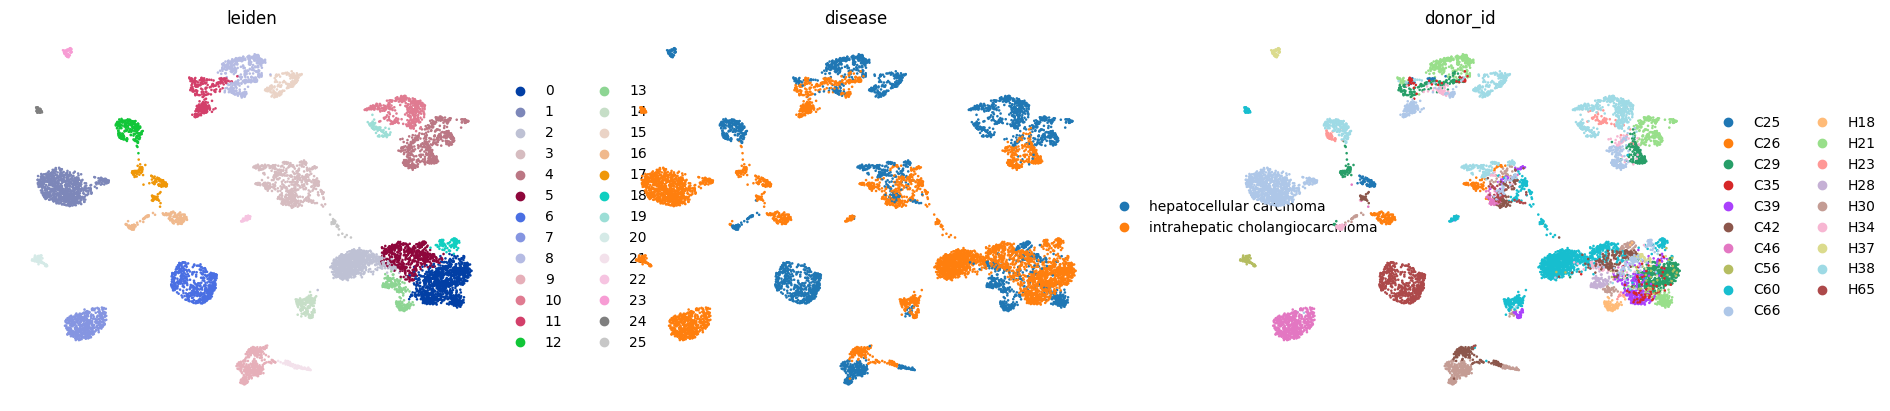

In [ ]:
sc.pl.umap(adata, color=["leiden", "disease", "donor_id"], frameon=False)


# Phase 4.5 — Visual sanity checks (clusters, disease, donor)





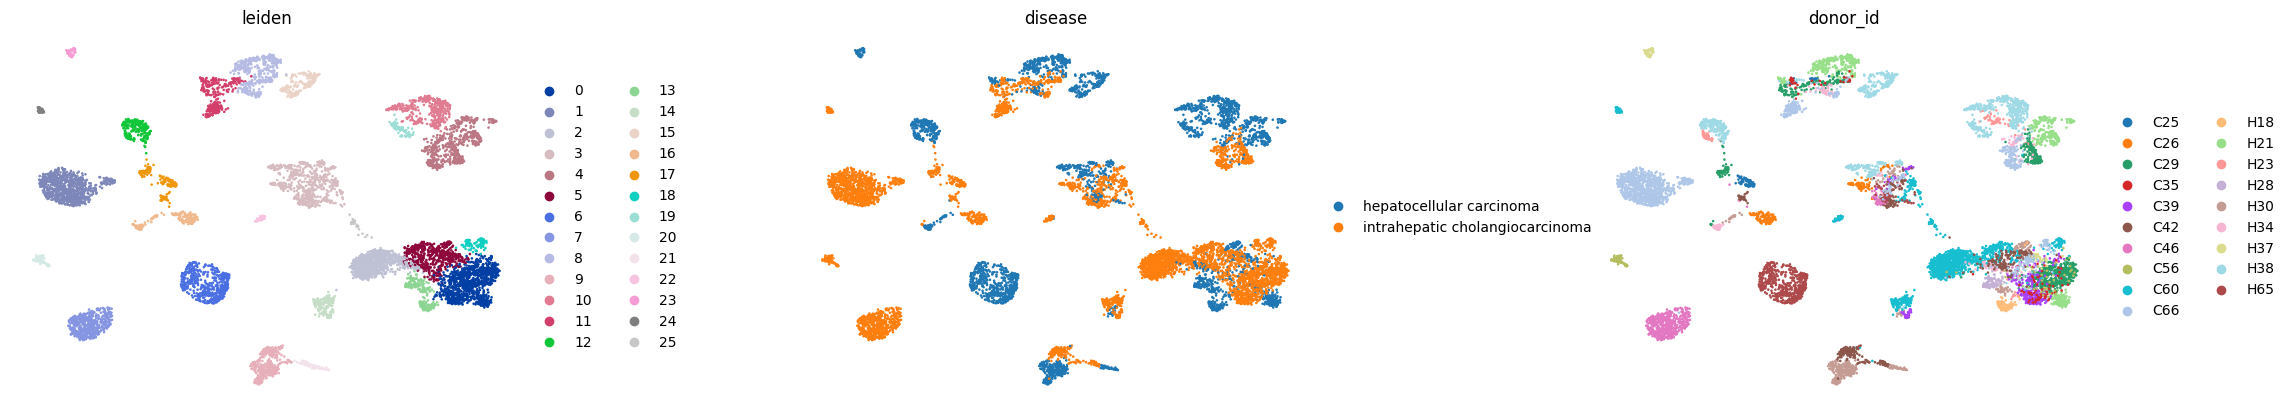

In [ ]:
import scanpy as sc

sc.pl.umap(
    adata,
    color=["leiden", "disease", "donor_id"],
    frameon=False,
    wspace=0.4
)


# **Phase 5 — Compartment orientation and marker validation**



Even if cell_type exists, we should validate with canonical markers.


# Phase 5.1 — Marker panels (liver cancer context)


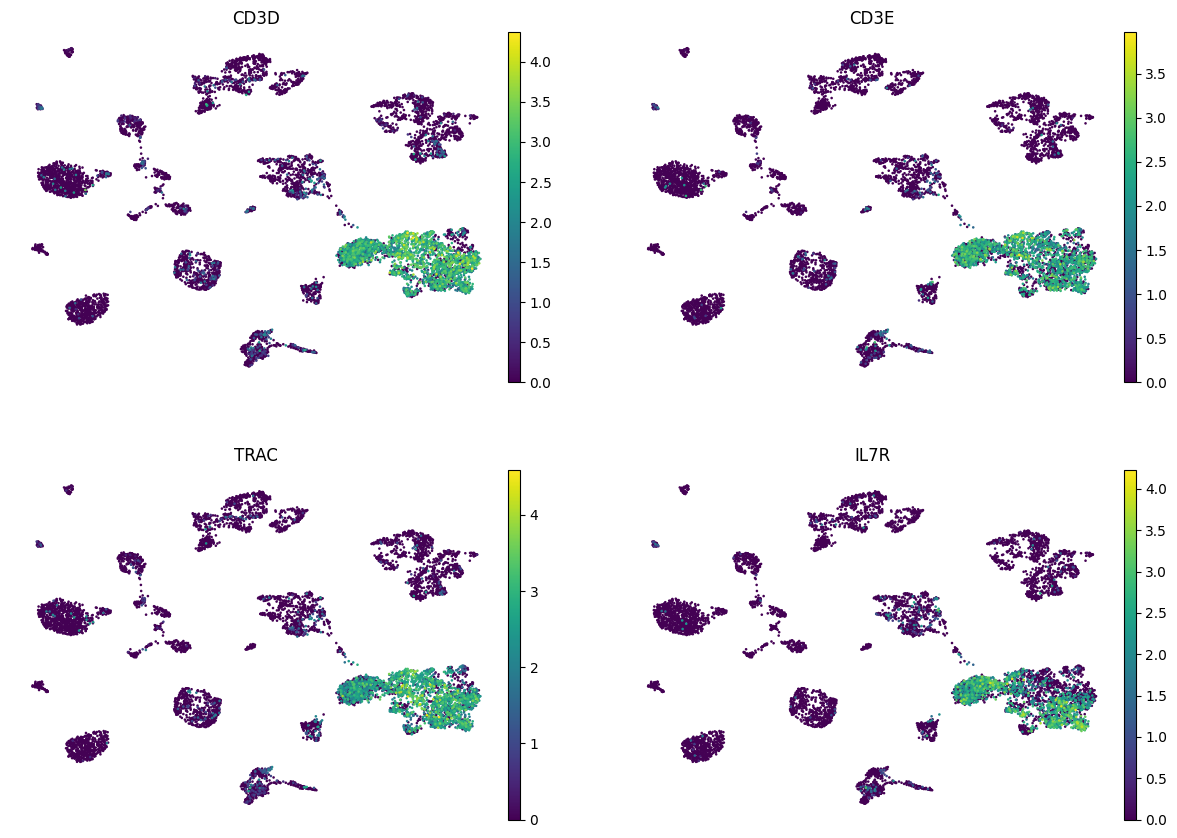

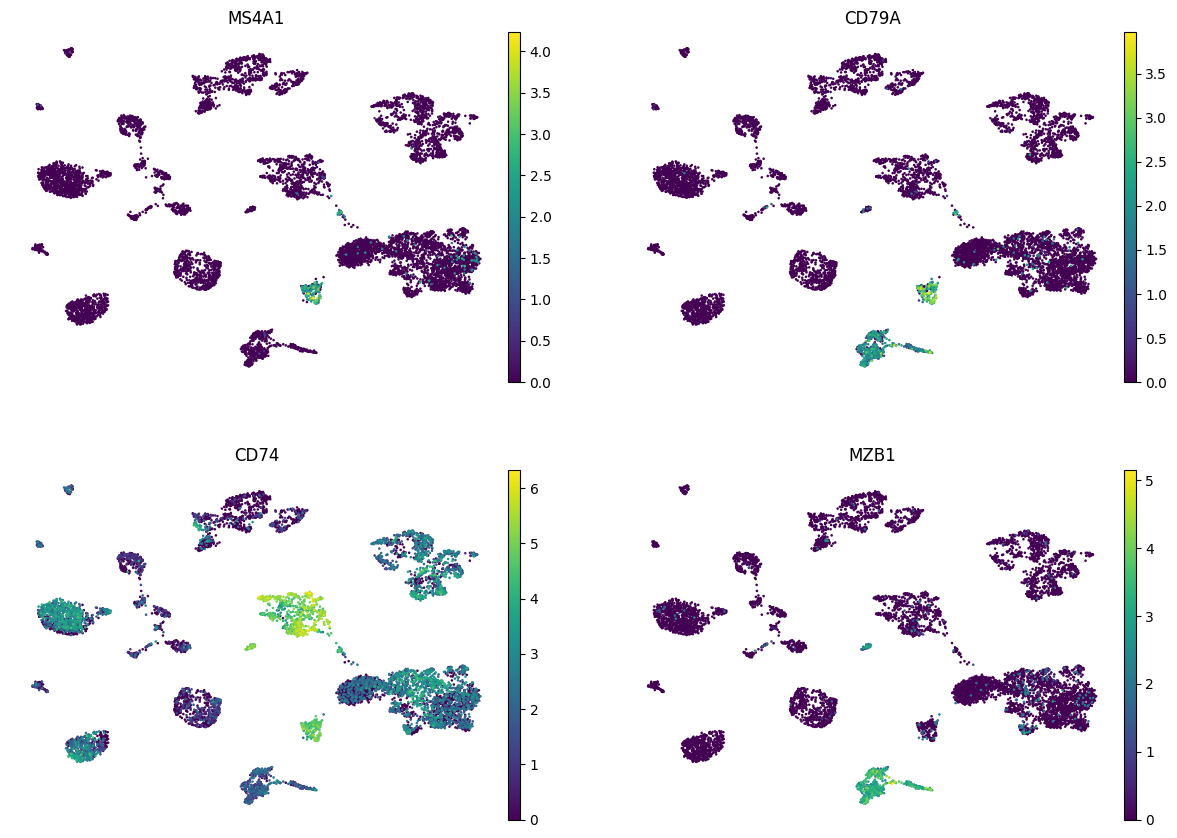

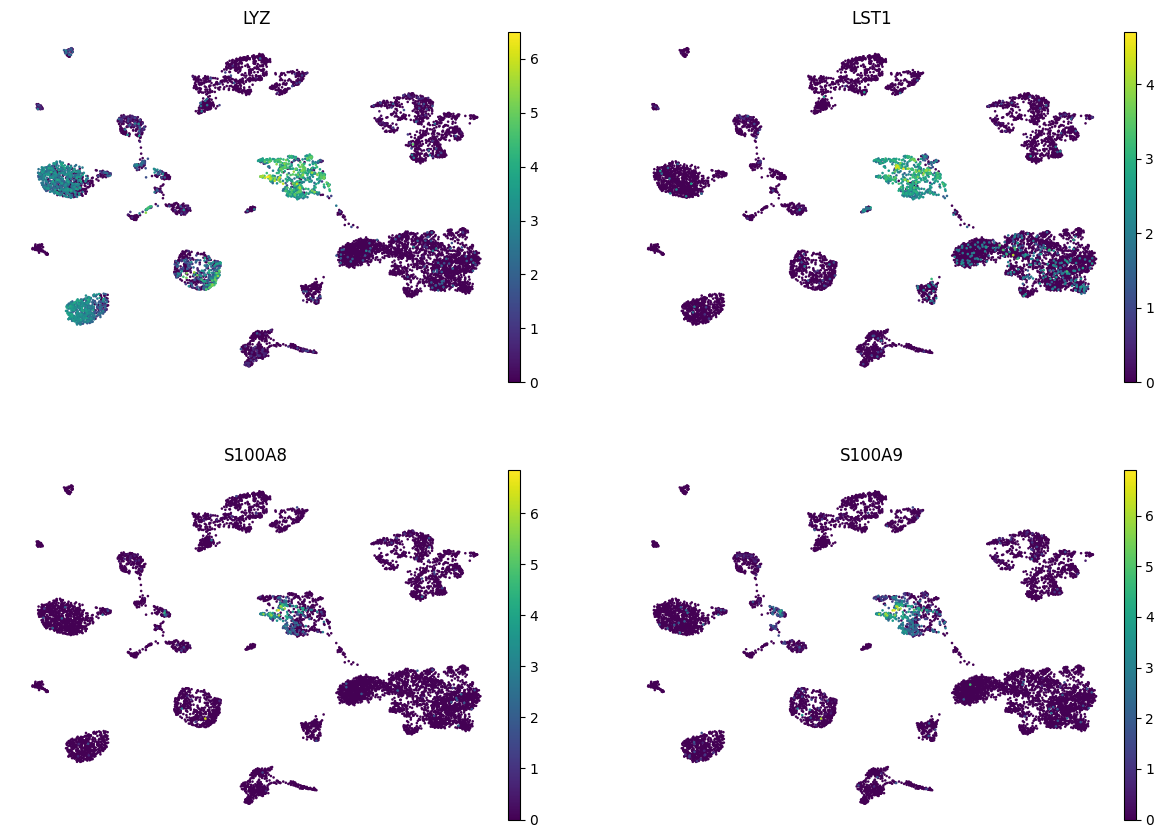

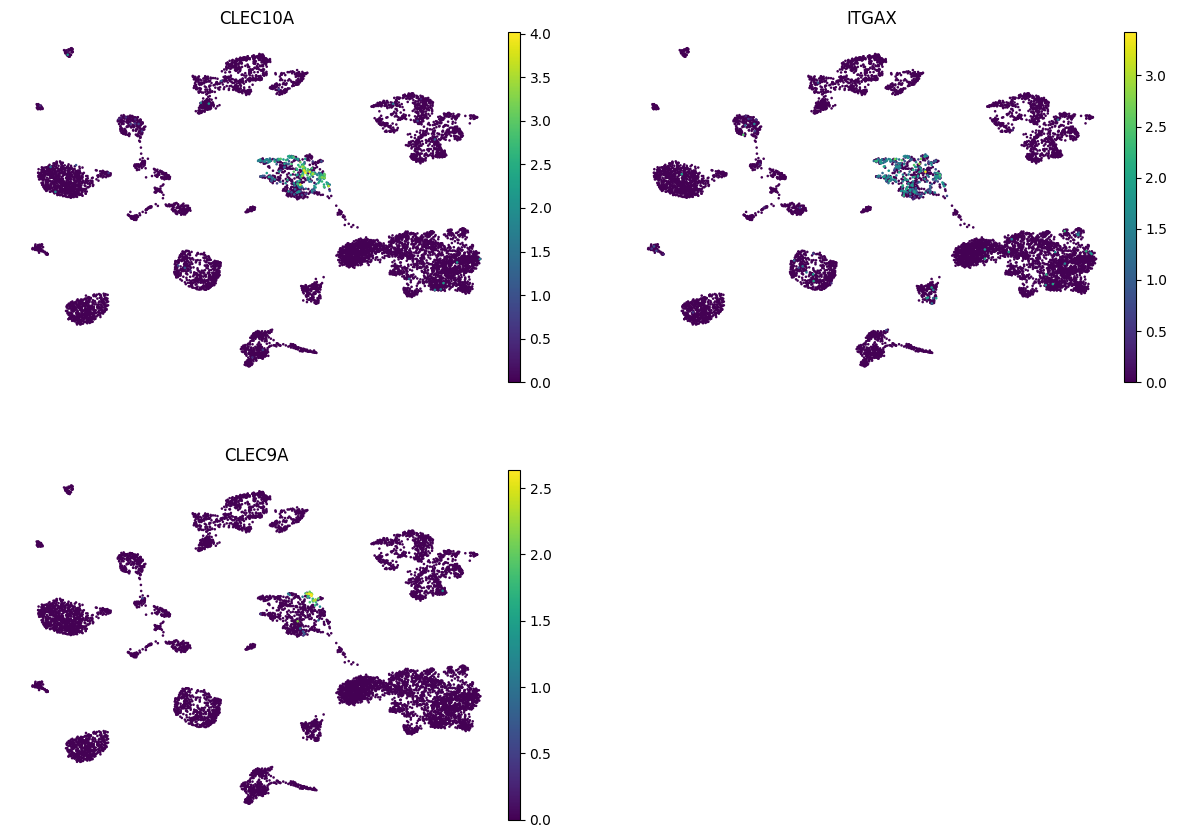

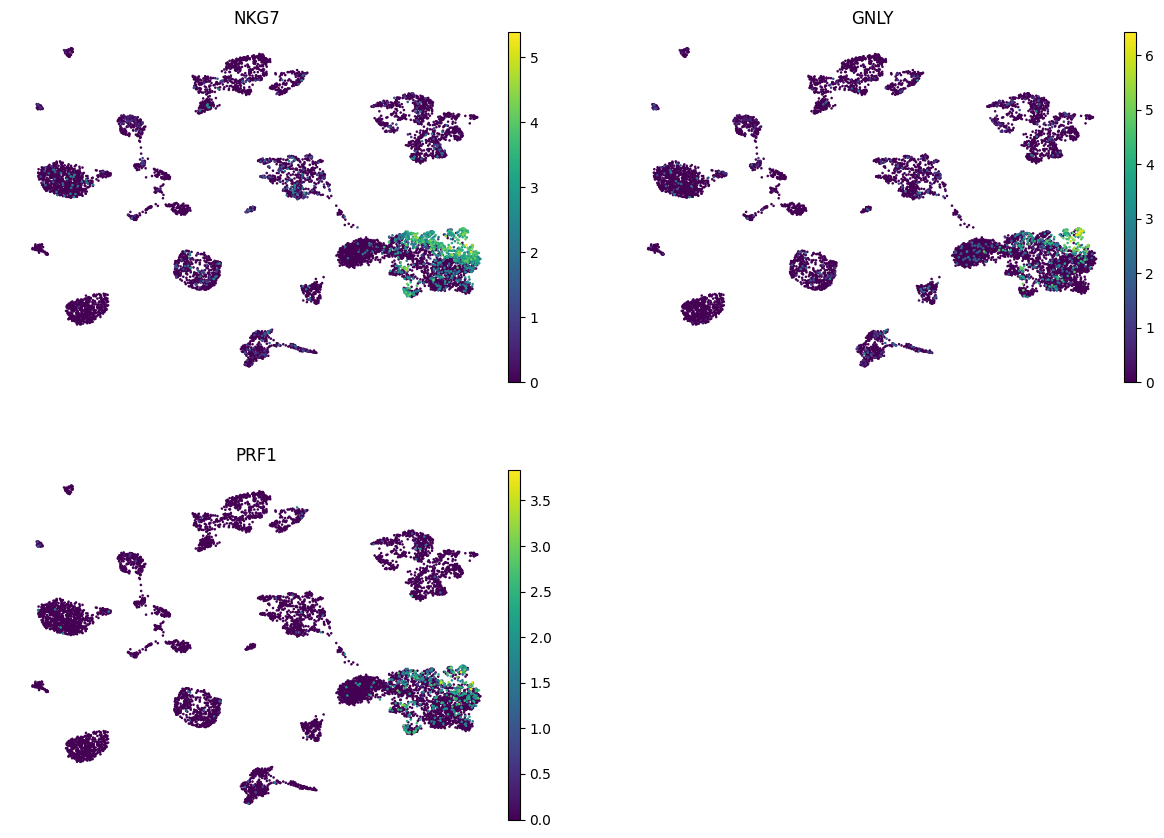

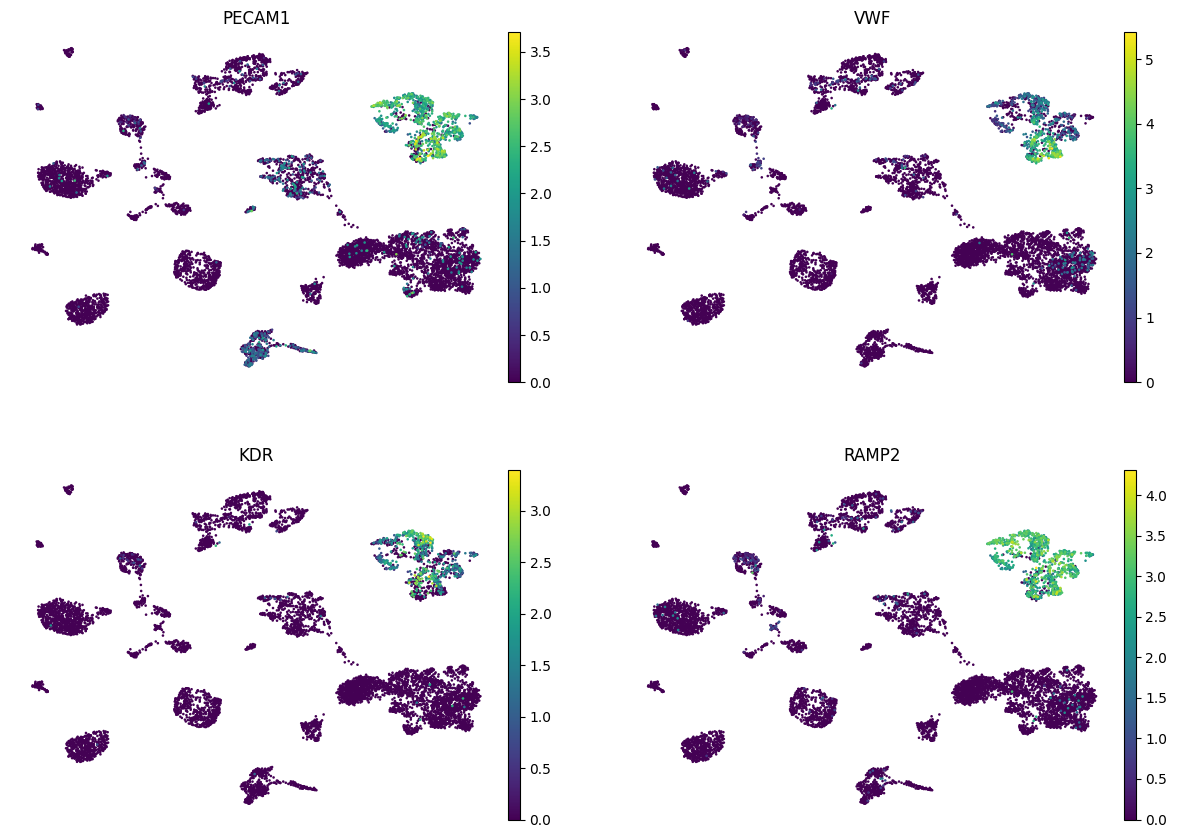

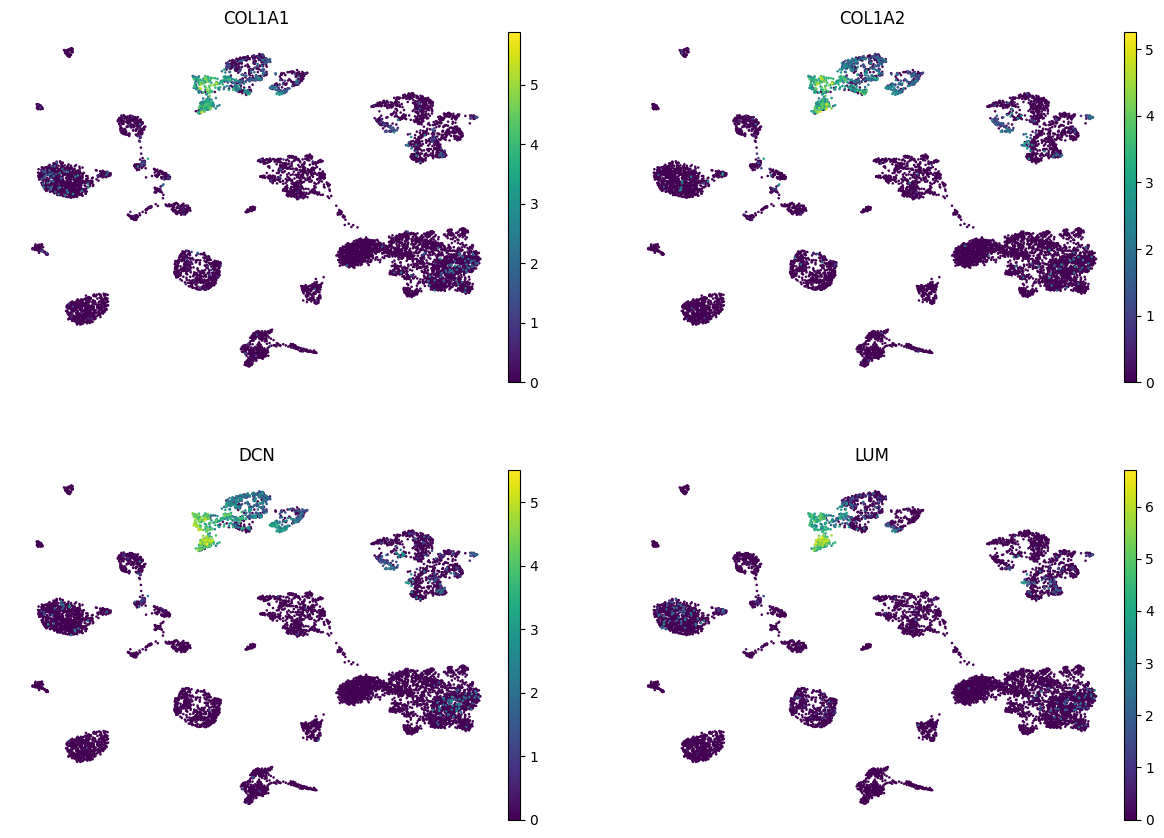

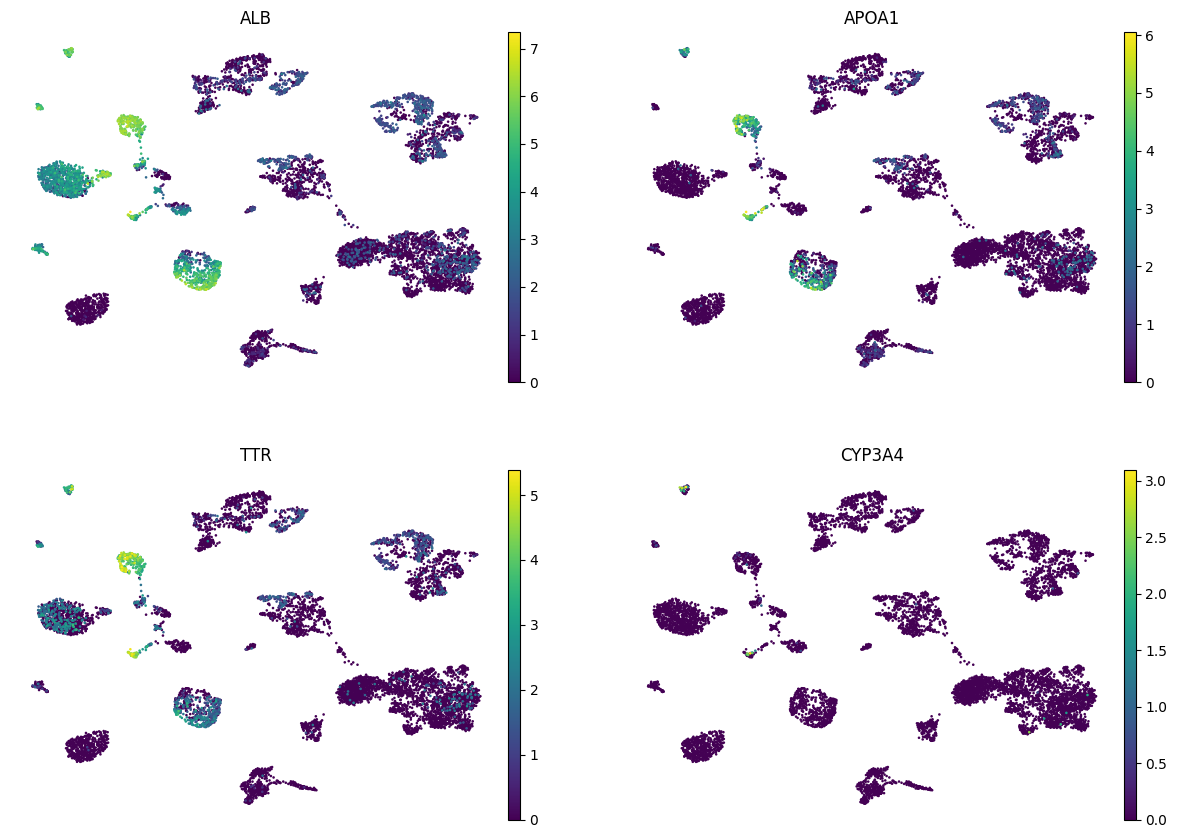

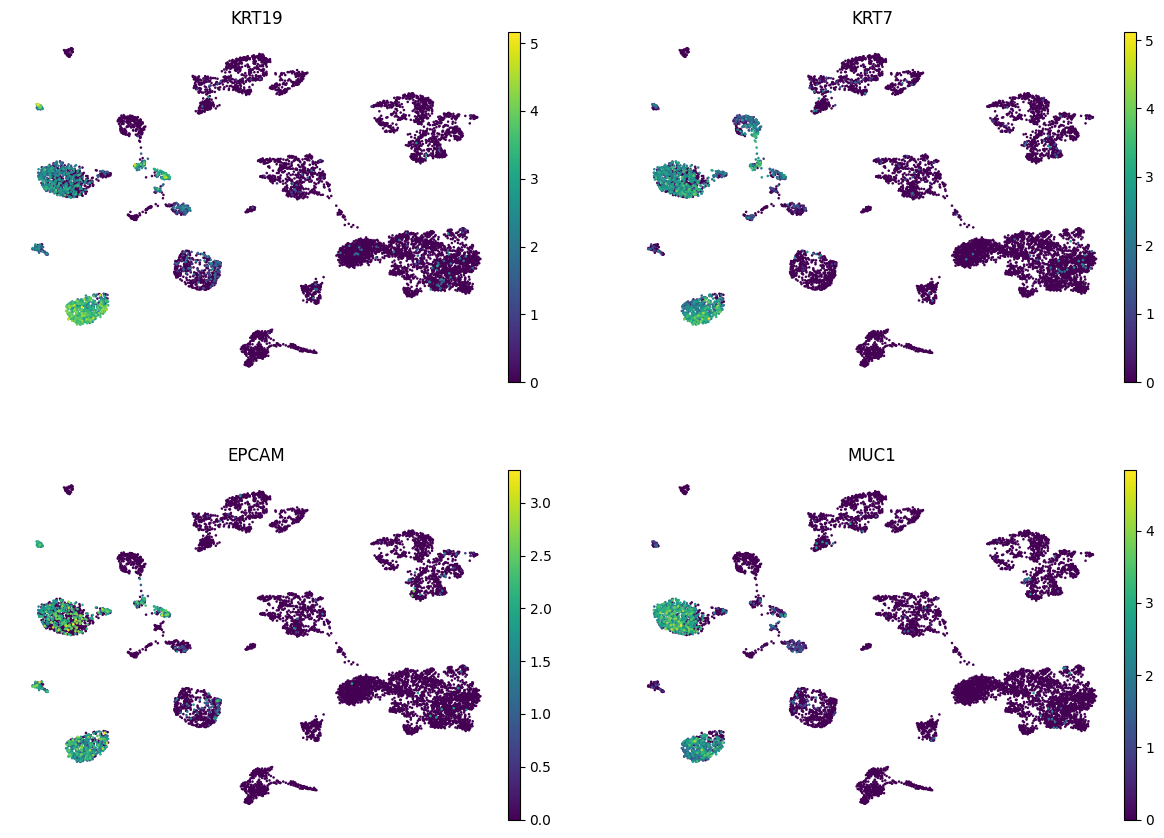

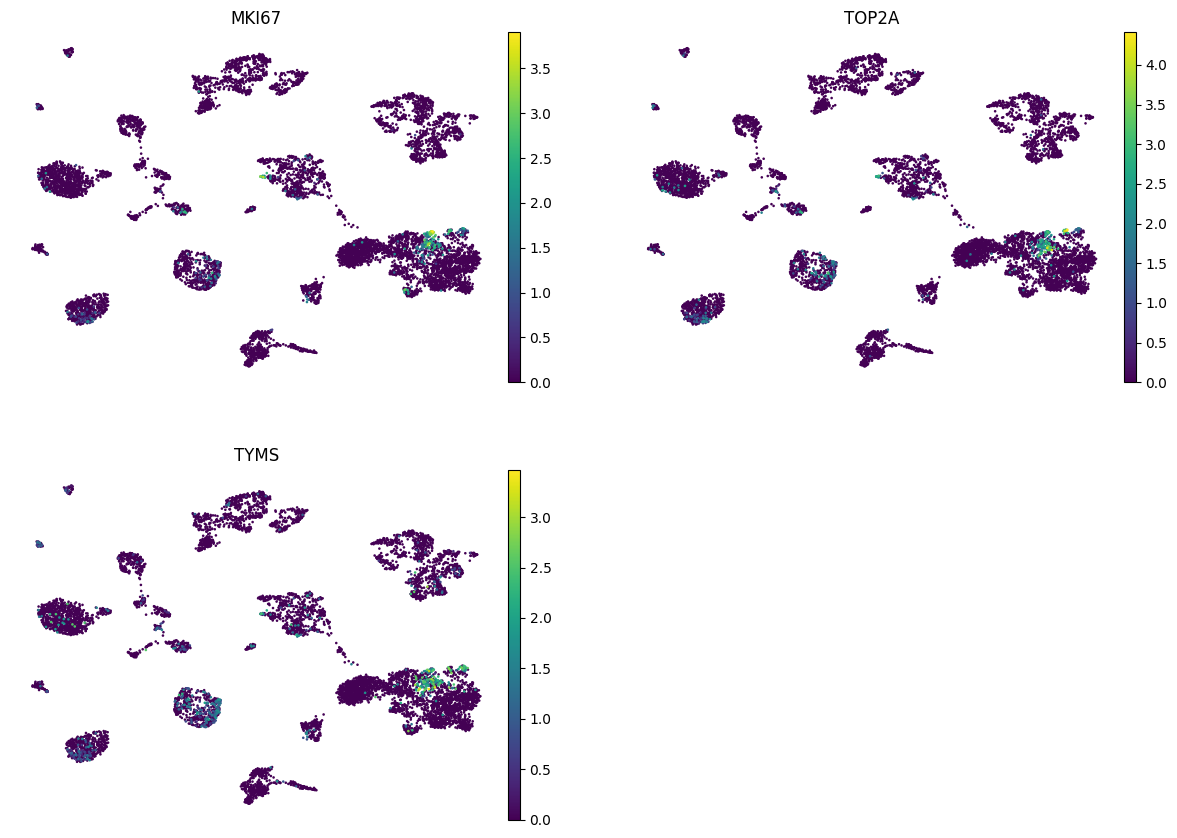

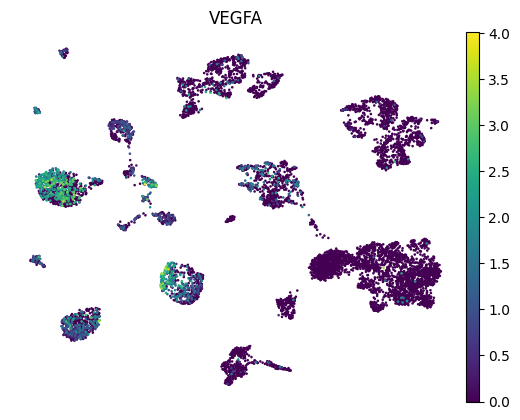

In [ ]:
marker_sets = {
    # Immune
    "T_cells": ["CD3D","CD3E","TRAC","IL7R","NKG7"],
    "B_cells": ["MS4A1","CD79A","CD74","MZB1"],
    "Myeloid": ["LYZ","LST1","S100A8","S100A9","FCGR3A","MS4A7"],
    "Dendritic": ["FCER1A","CLEC10A","ITGAX","CLEC9A"],
    "NK": ["NKG7","GNLY","PRF1"],

    # Stromal / vascular
    "Endothelial": ["PECAM1","VWF","KDR","RAMP2"],
    "Fibroblast/CAF": ["COL1A1","COL1A2","DCN","LUM","ACTA2","TAGLN"],

    # Liver lineage / malignant candidates
    "Hepatocyte_like": ["ALB","APOA1","APOB","TTR","CYP3A4"],
    "Cholangiocyte_like": ["KRT19","KRT7","EPCAM","MUC1","SOX9"],

    # Proliferation / stress
    "Proliferation": ["MKI67","TOP2A","PCNA","TYMS"],
    "Hypoxia_Glycolysis": ["HIF1A","VEGFA","SLC2A1","LDHA","ENO1"],
}

for name, genes in marker_sets.items():
    genes_present = [g for g in genes if g in adata.var_names]
    if genes_present:
        sc.pl.umap(adata, color=genes_present[:4], frameon=False, ncols=2)
    else:
        print(f"{name}: none of the markers found in var_names")


# 5.2 — Use existing cell_type annotations (if reliable)



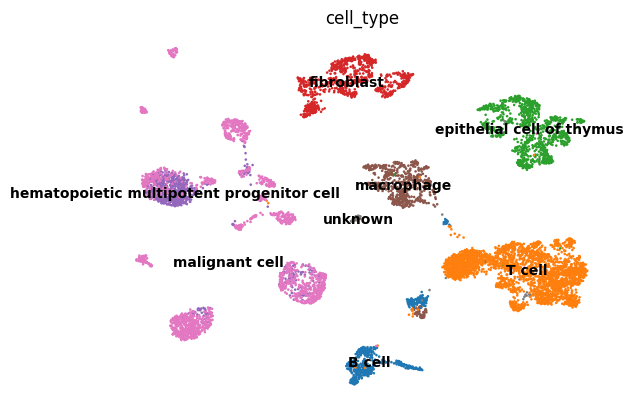

In [ ]:
if "cell_type" in adata.obs.columns:
    sc.pl.umap(adata, color=["cell_type"], frameon=False, legend_loc="on data")


# **Phase 6 — First hypothesis module: immune dysfunction vs myeloid suppression**

Score gene programs rather than over-interpret clusters immediately.


# Phase 6.1 — Program scoring (exhaustion, Treg, myeloid inflammation)


T_exhaustion scored with 5 genes
Treg scored with 5 genes
Myeloid_inflam scored with 5 genes


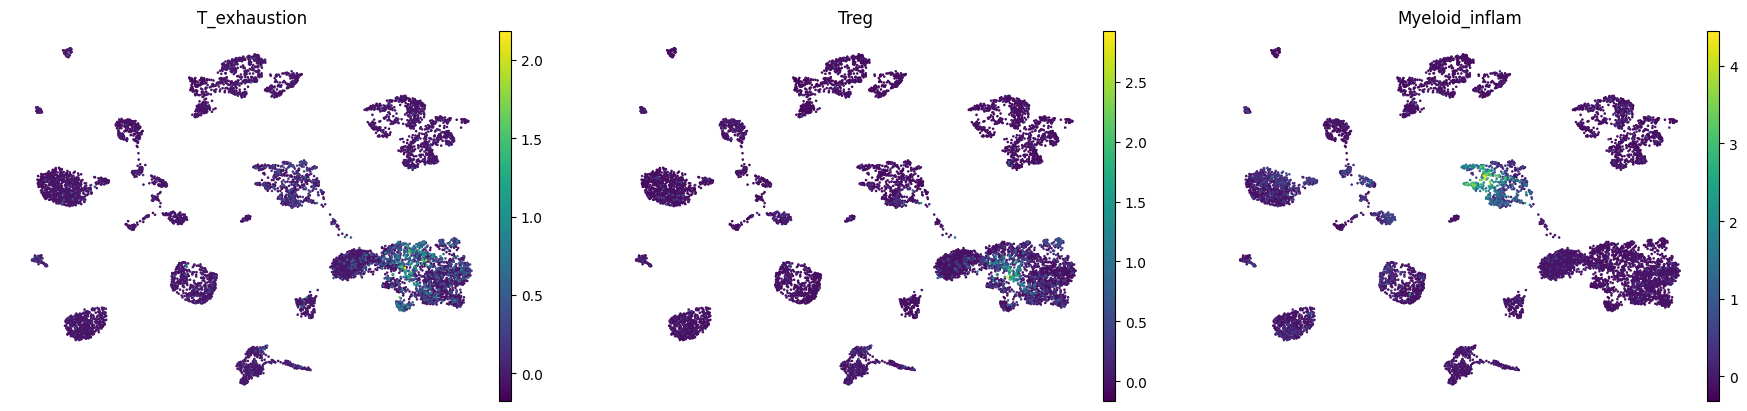

In [ ]:
def score_genes_safe(adata, gene_list, score_name):
    gl = [g for g in gene_list if g in adata.var_names]
    if len(gl) >= 4:
        sc.tl.score_genes(adata, gl, score_name=score_name)
        print(score_name, "scored with", len(gl), "genes")
    else:
        print("Skipping", score_name, "- too few genes present:", gl)

score_genes_safe(adata, ["PDCD1","LAG3","HAVCR2","TIGIT","CTLA4","TOX"], "T_exhaustion")
score_genes_safe(adata, ["FOXP3","IL2RA","CTLA4","IKZF2","TNFRSF18"], "Treg")
score_genes_safe(adata, ["S100A8","S100A9","LGALS3","IL1B","CXCL8","FCN1"], "Myeloid_inflam")

sc.pl.umap(adata, color=["T_exhaustion","Treg","Myeloid_inflam"], frameon=False)


# **Phase 7B — Marker-score-defined tumor subset**

# Phase 7B.1 — Score tumor-lineage vs immune/stromal programs

In [ ]:
import scanpy as sc
import numpy as np

def score_genes_safe(adata, genes, name):
    g = [x for x in genes if x in adata.var_names]
    if len(g) >= 4:
        sc.tl.score_genes(adata, g, score_name=name)
        print(f"{name}: scored with {len(g)} genes")
    else:
        print(f"{name}: skipped (too few genes present) -> {g}")

# Tumor lineage candidates (HCC-like vs iCCA-like)
score_genes_safe(adata, ["ALB","APOA1","APOB","TTR","CYP3A4","ASGR1"], "Hep_like")
score_genes_safe(adata, ["KRT19","KRT7","EPCAM","SOX9","MUC1","KRT8","KRT18"], "Chol_like")

# “Anti-tumor-lineage” (exclude non-tumor compartments)
score_genes_safe(adata, ["CD3D","CD3E","TRAC","IL7R","NKG7"], "T_NK_like")
score_genes_safe(adata, ["MS4A1","CD79A","CD74","MZB1"], "B_like")
score_genes_safe(adata, ["LYZ","LST1","S100A8","S100A9","FCGR3A","MS4A7"], "Myeloid_like")
score_genes_safe(adata, ["PECAM1","VWF","KDR","RAMP2"], "Endo_like")
score_genes_safe(adata, ["COL1A1","COL1A2","DCN","LUM","ACTA2"], "Fib_like")


Hep_like: scored with 5 genes
Chol_like: scored with 7 genes
T_NK_like: scored with 5 genes
B_like: scored with 4 genes
Myeloid_like: scored with 6 genes
Endo_like: scored with 4 genes
Fib_like: scored with 5 genes


# Phase 7B.2 — Define tumor mask (robust and adjustable)

This defines tumor-like cells as those with high hepatocyte/cholangiocyte score and low immune/stromal score.

In [ ]:
# Composite scores
adata.obs["Tumor_lineage_score"] = adata.obs.get("Hep_like", 0) + adata.obs.get("Chol_like", 0)
adata.obs["Non_tumor_score"] = (
    adata.obs.get("T_NK_like", 0) +
    adata.obs.get("B_like", 0) +
    adata.obs.get("Myeloid_like", 0) +
    adata.obs.get("Endo_like", 0) +
    adata.obs.get("Fib_like", 0)
)

# Conservative thresholds using quantiles (stable across datasets)
tum_q = adata.obs["Tumor_lineage_score"].quantile(0.70)
non_q = adata.obs["Non_tumor_score"].quantile(0.70)

tumor_mask = (adata.obs["Tumor_lineage_score"] >= tum_q) & (adata.obs["Non_tumor_score"] <= non_q)

print("Tumor-lineage score threshold (70th pct):", tum_q)
print("Non-tumor score threshold (70th pct):", non_q)
print("Tumor-like cells selected:", int(tumor_mask.sum()), "/", adata.n_obs)

adata.obs["is_tumor_like"] = tumor_mask


Tumor-lineage score threshold (70th pct): 0.19353955443078946
Non-tumor score threshold (70th pct): 0.7288050381319392
Tumor-like cells selected: 2543 / 8683


# Phase 7B.3 — Sanity plots (ensure that gating makes biological sense)

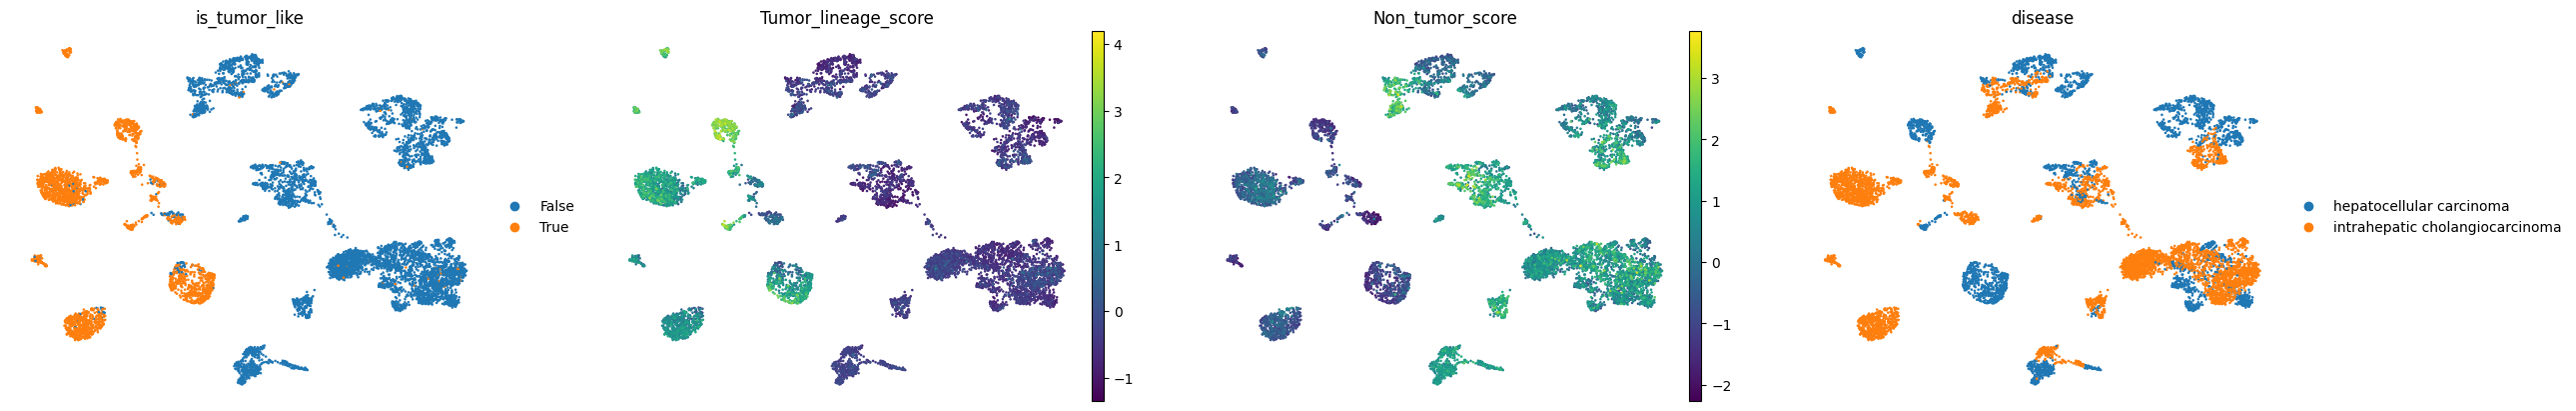

In [ ]:
sc.pl.umap(adata, color=["is_tumor_like","Tumor_lineage_score","Non_tumor_score","disease"], frameon=False)


# Phase 7B.4 — Create tumor-only AnnData

In [ ]:
adata_tum = adata[adata.obs["is_tumor_like"]].copy()
print("Tumor-only AnnData:", adata_tum.shape)


Tumor-only AnnData: (2543, 3000)


# **Phase 7B.5A — Remove suspect non-tumor clusters (tumor-purity tighten)**

The functions serve as an approach that is fast, controlled, and preserves most malignant cells while removing residual immune/stromal contamination that leaked through marker-score gating.

*Identify “suspect” tumor_leiden clusters by marker content*

# Phase 7B.5A.1 — Compute quick markers per tumor cluster

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# Pick the best available tumor clustering key
candidate_keys = ["tumor_leiden", "tumor_leiden_pure", "leiden", "louvain"]
groupby_key = next((k for k in adata_tum.obs.columns if k in candidate_keys), None)

if groupby_key is None:
    raise KeyError(f"No clustering key found in adata_tum.obs. Available columns include: {list(adata_tum.obs.columns)[:40]}")

print("Using groupby key:", groupby_key)

# Identify groups with only one sample
group_counts = adata_tum.obs[groupby_key].value_counts()
singleton_groups = group_counts[group_counts == 1].index.tolist()

if singleton_groups:
    print(f"Excluding groups with single samples: {singleton_groups}")
    # Create a temporary AnnData object excluding these singleton groups
    adata_tum_filtered = adata_tum[~adata_tum.obs[groupby_key].isin(singleton_groups)].copy()
    # Ensure the groupby_key category is updated after removing singletons
    adata_tum_filtered.obs[groupby_key] = adata_tum_filtered.obs[groupby_key].cat.remove_unused_categories()
else:
    adata_tum_filtered = adata_tum.copy()

# Check if 'rank_genes_groups' has been computed and is complete for the current groupby_key
rank_genes_groups_exists = (
    "rank_genes_groups" in adata_tum_filtered.uns
    and "names" in adata_tum_filtered.uns["rank_genes_groups"]
    and adata_tum_filtered.uns["rank_genes_groups"].get("params", {}).get("groupby", None) == groupby_key
)

if not rank_genes_groups_exists:
    print("Re-computing rank_genes_groups...")
    sc.tl.rank_genes_groups(adata_tum_filtered, groupby=groupby_key, method="wilcoxon", pts=True)
else:
    print("rank_genes_groups already computed and complete for this key.")

# Now, adata_tum_filtered.uns['rank_genes_groups'] *should* be fully populated.
rank_genes_groups_data = adata_tum_filtered.uns['rank_genes_groups']

# Get the list of groups (clusters) from the structured array 'names' field
groups_from_rgg = rank_genes_groups_data['names'].dtype.names

# Retrieve markers for each group individually and concatenate them
markers_list = []
for g in groups_from_rgg:
    # Extract data for the current group directly from the structured array
    names = rank_genes_groups_data['names'][g]
    scores = rank_genes_groups_data['scores'][g]
    logfoldchanges = rank_genes_groups_data['logfoldchanges'][g]
    pvals = rank_genes_groups_data['pvals'][g]
    pvals_adj = rank_genes_groups_data['pvals_adj'][g]

    # Create a temporary DataFrame for this group
    df_group = pd.DataFrame({
        'names': names,
        'scores': scores,
        'logfoldchanges': logfoldchanges,
        'pvals': pvals,
        'pvals_adj': pvals_adj,
        'group': g  # Add group identifier
    })
    markers_list.append(df_group)

if markers_list:
    markers = pd.concat(markers_list, ignore_index=False)
else:
    markers = pd.DataFrame() # Handle case with no groups

# Show top 15 genes per cluster
topn = 15
top_markers = (
    markers.sort_values(["group", "scores"], ascending=[True, False])
           .groupby("group")
           .head(topn)
)

display(top_markers.head(60))


Using groupby key: leiden
Excluding groups with single samples: ['3', '25']
Re-computing rank_genes_groups...


,names,scores,logfoldchanges,pvals,pvals_adj,group
0,CXCR4,7.483352,8.317861,7.245031e-14,2.173509e-10,0
1,CD52,6.153317,6.406627,7.587899e-10,7.587899e-07,0
2,S100A4,6.092268,4.268662,1.113217e-09,8.349126e-07,0
3,ANXA1,5.155359,4.826956,2.531459e-07,7.594377e-05,0
4,CD48,5.089446,7.503325,3.591122e-07,8.977805e-05,0
5,CD69,5.026043,6.702710,5.007033e-07,1.155469e-04,0
6,CRIP1,4.737908,4.550471,2.159358e-06,3.727701e-04,0
7,VIM,4.685648,3.890441,2.790752e-06,3.805571e-04,0
8,TRBC1,4.234770,6.270936,2.287856e-05,2.451274e-03,0
9,TRBC2,4.193653,5.866326,2.744980e-05,2.839635e-03,0


# Phase 7B.5A.2 — Flag clusters with immune/stromal marker hits

In [ ]:
import pandas as pd

suspect_genes = {
    # Immune
    "T_NK": ["TRAC","CD3D","CD3E","NKG7","GNLY","PRF1","GZMB","KLRD1"],
    "B_plasma": ["MS4A1","CD79A","CD74","MZB1","JCHAIN","IGHG1","IGKC"],
    "Myeloid": ["LYZ","LST1","S100A8","S100A9","FCGR3A","MS4A7","TYROBP"],
    # Stromal / vascular
    "Endo": ["PECAM1","VWF","KDR","RAMP2","EMCN"],
    "Fib": ["COL1A1","COL1A2","DCN","LUM","ACTA2","TAGLN"]
}
suspect_flat = set(g for lst in suspect_genes.values() for g in lst)

# Use top_markers created in 7B.5A.1
cluster_flags = []
for cl, df in top_markers.groupby("group"):
    genes = set(df["names"].astype(str))
    hits = sorted(list(genes.intersection(suspect_flat)))
    cluster_flags.append({groupby_key: str(cl), "suspect_hits": ", ".join(hits), "n_hits": len(hits)})

flags = pd.DataFrame(cluster_flags).sort_values("n_hits", ascending=False)
display(flags)

,leiden,suspect_hits,n_hits
1,1,"CD74, IGKC",2
2,10,"EMCN, RAMP2",2
14,5,"CD3E, LST1",2
3,11,"DCN, IGKC",2
6,15,"ACTA2, TAGLN",2
17,8,"ACTA2, TAGLN",2
0,0,CD3D,1
13,4,EMCN,1
9,2,CD3D,1
5,13,,0


# Phase 7B.5A.3- (define drop list + build adata_tum_pure)

In [ ]:
HIT_THRESHOLD = 2  # conservative: drop clusters with >=2 immune/stromal hallmark hits in top markers

drop_clusters = flags.loc[flags["n_hits"] >= HIT_THRESHOLD, groupby_key].tolist()
print("Proposed drop clusters:", drop_clusters)

adata_tum_pure = adata_tum[~adata_tum.obs[groupby_key].astype(str).isin(drop_clusters)].copy()
print("Before:", adata_tum.shape, " After:", adata_tum_pure.shape)

Proposed drop clusters: ['1', '10', '5', '11', '15', '8']
Before: (2543, 3000)  After: (1656, 3000)


# Phase 7B.5A.4- Quick sanity visualization (confirm we removed the right clusters)


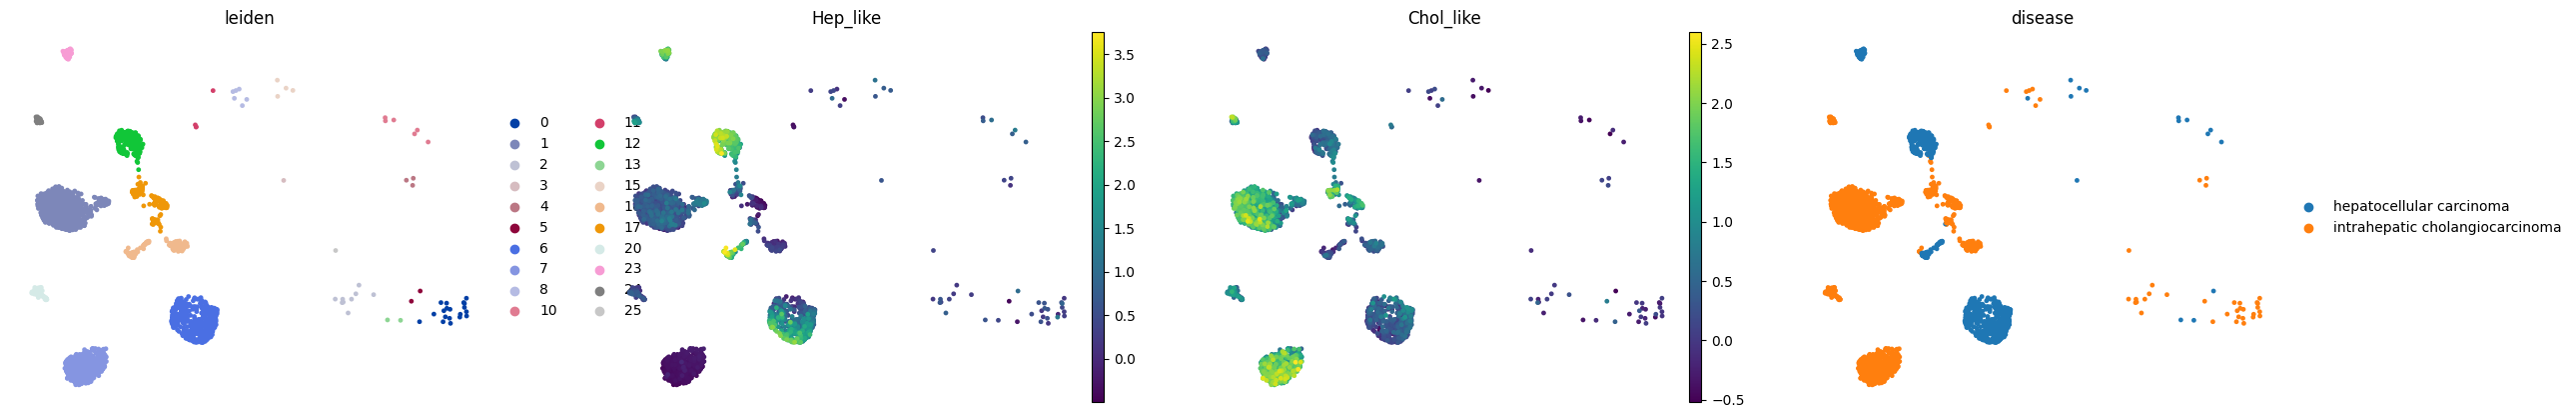

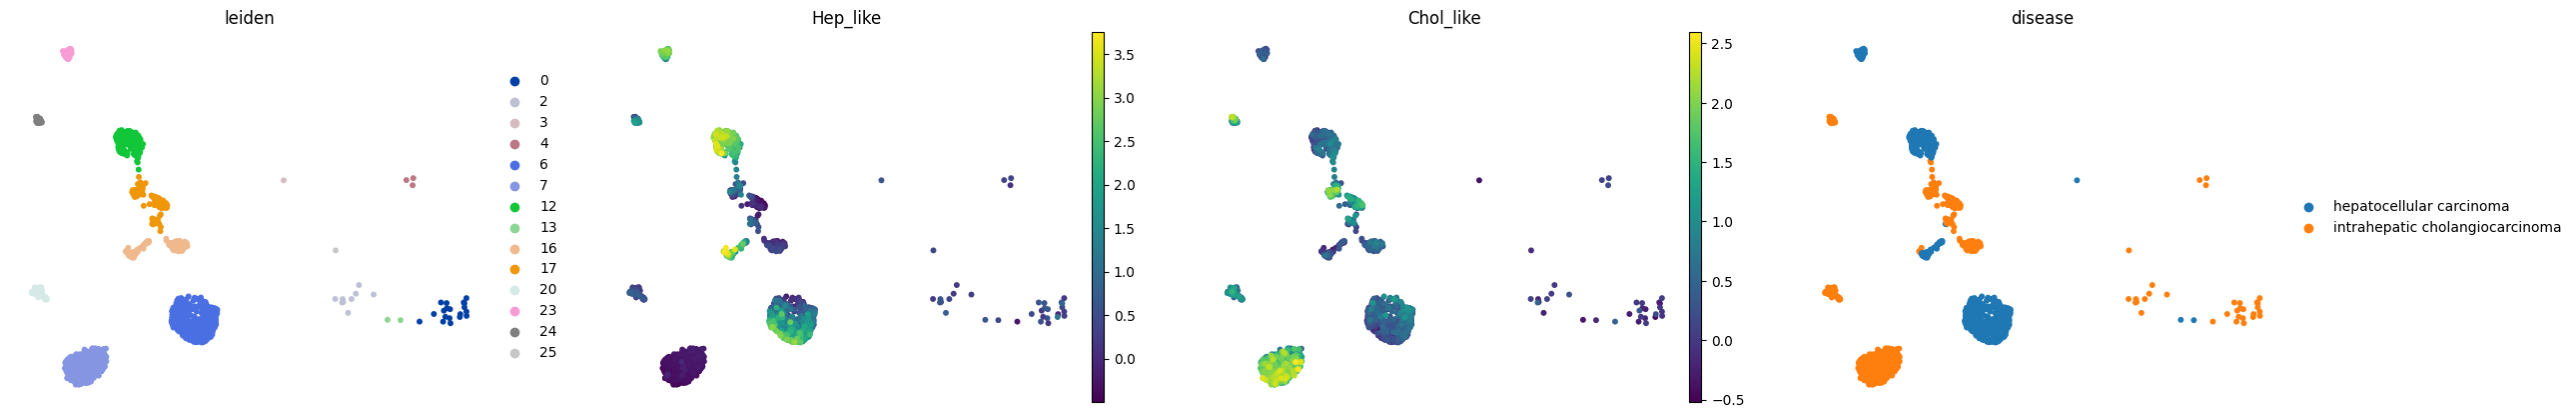

In [ ]:
import scanpy as sc

sc.pl.umap(adata_tum, color=["leiden","Hep_like","Chol_like","disease"], frameon=False)
sc.pl.umap(adata_tum_pure, color=["leiden","Hep_like","Chol_like","disease"], frameon=False)

# Recreate tumor clusters explicitly as tumor_leiden

# Rerun the tumor-only embedding step and ensure tumor_leiden exists:

In [ ]:
sc.tl.pca(adata_tum, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_tum, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata_tum, resolution=0.6, key_added="tumor_leiden")
sc.tl.umap(adata_tum)


# **Phase 7C — Tumor-only re-embedding and tumor states**

# Phase 7C.1 — Re-run HVG → PCA → neighbors → Leiden → UMAP on tumor-only

In [ ]:
sc.pp.normalize_total(adata_tum, target_sum=1e4)
sc.pp.log1p(adata_tum)

sc.pp.highly_variable_genes(adata_tum, n_top_genes=2000, flavor="cell_ranger")
adata_tum = adata_tum[:, adata_tum.var.highly_variable].copy()

sc.tl.pca(adata_tum, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_tum, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata_tum, resolution=0.6, key_added="tumor_leiden")
sc.tl.umap(adata_tum)

adata_tum


AnnData object with n_obs × n_vars = 2543 × 2000
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'T_exhaustion', 'Treg', 'Myeloid_inflam', 'Hep_like', 'Chol_like', 'T_NK_like', 'B_like', 'Mye

# Phase 7C.2 — Tumor-only UMAP overlays

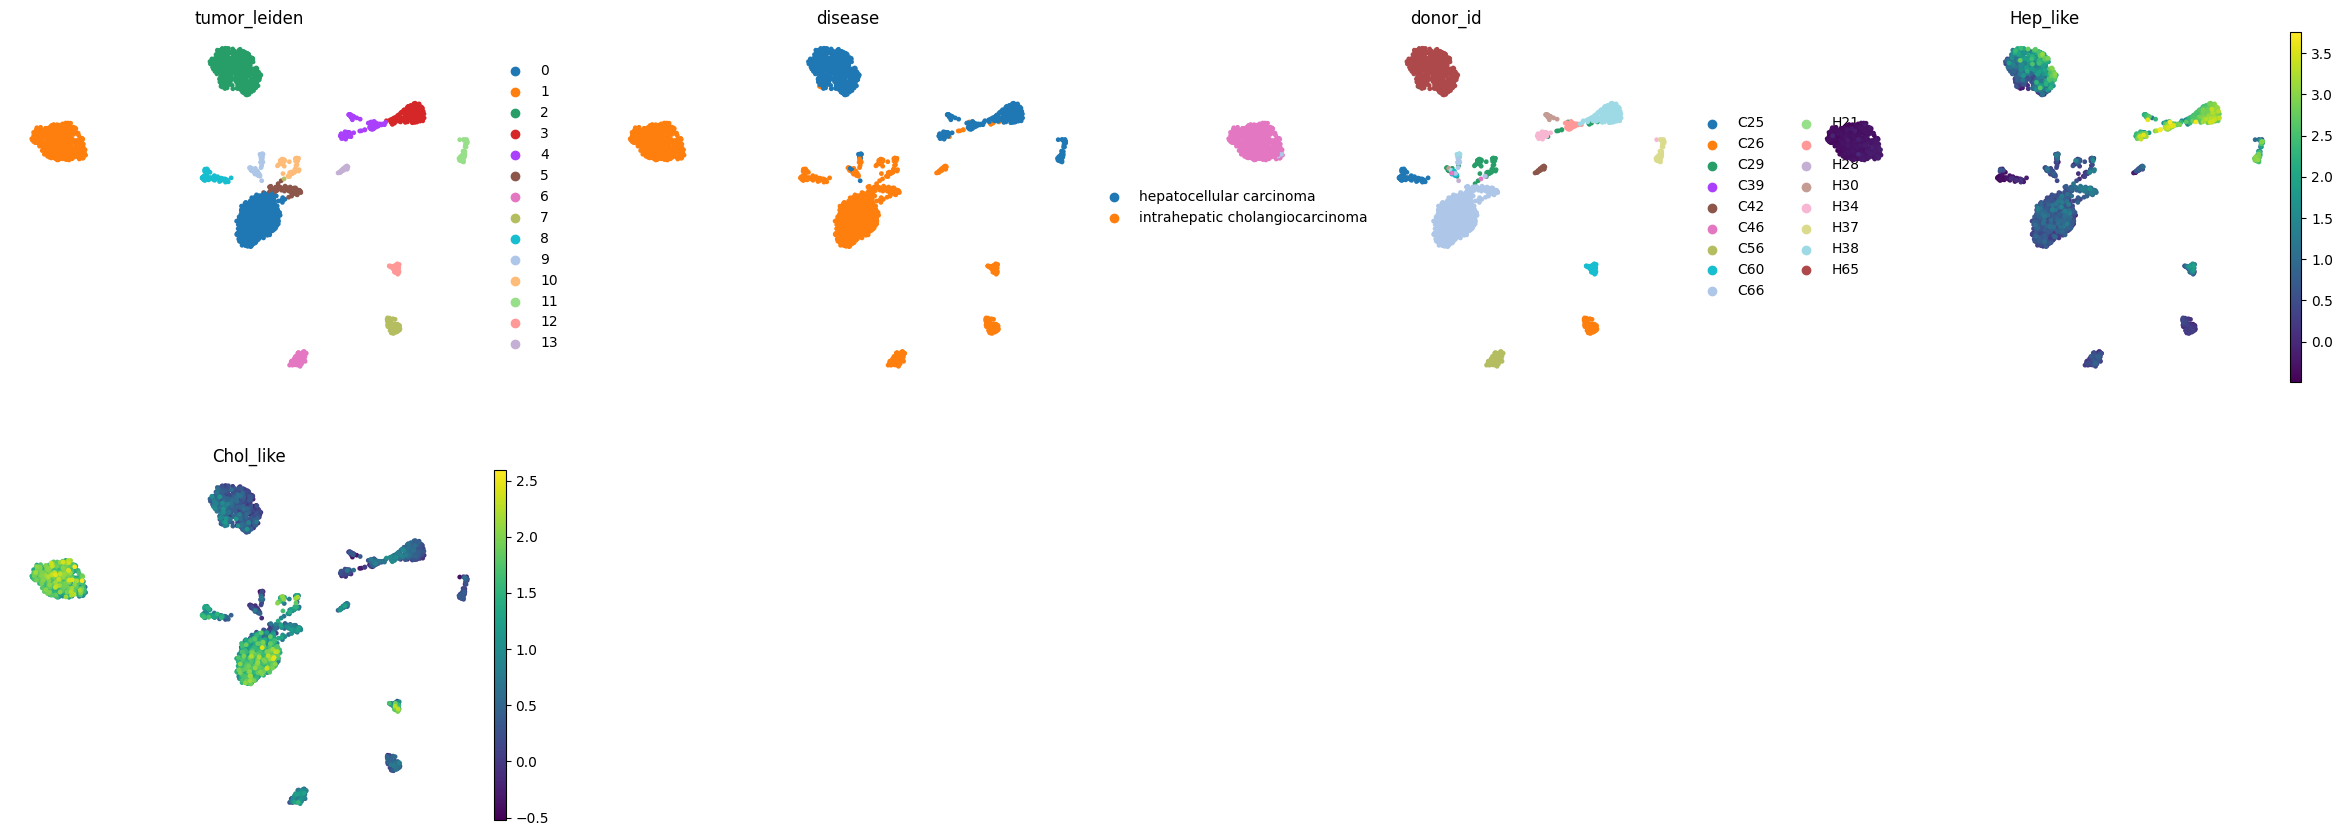

In [ ]:
sc.pl.umap(adata_tum, color=["tumor_leiden","disease","donor_id","Hep_like","Chol_like"], frameon=False)


# **Phase 7D — Differential Expression (required)**

# Phase 7D.1 — DE: tumor state markers (cluster vs rest)

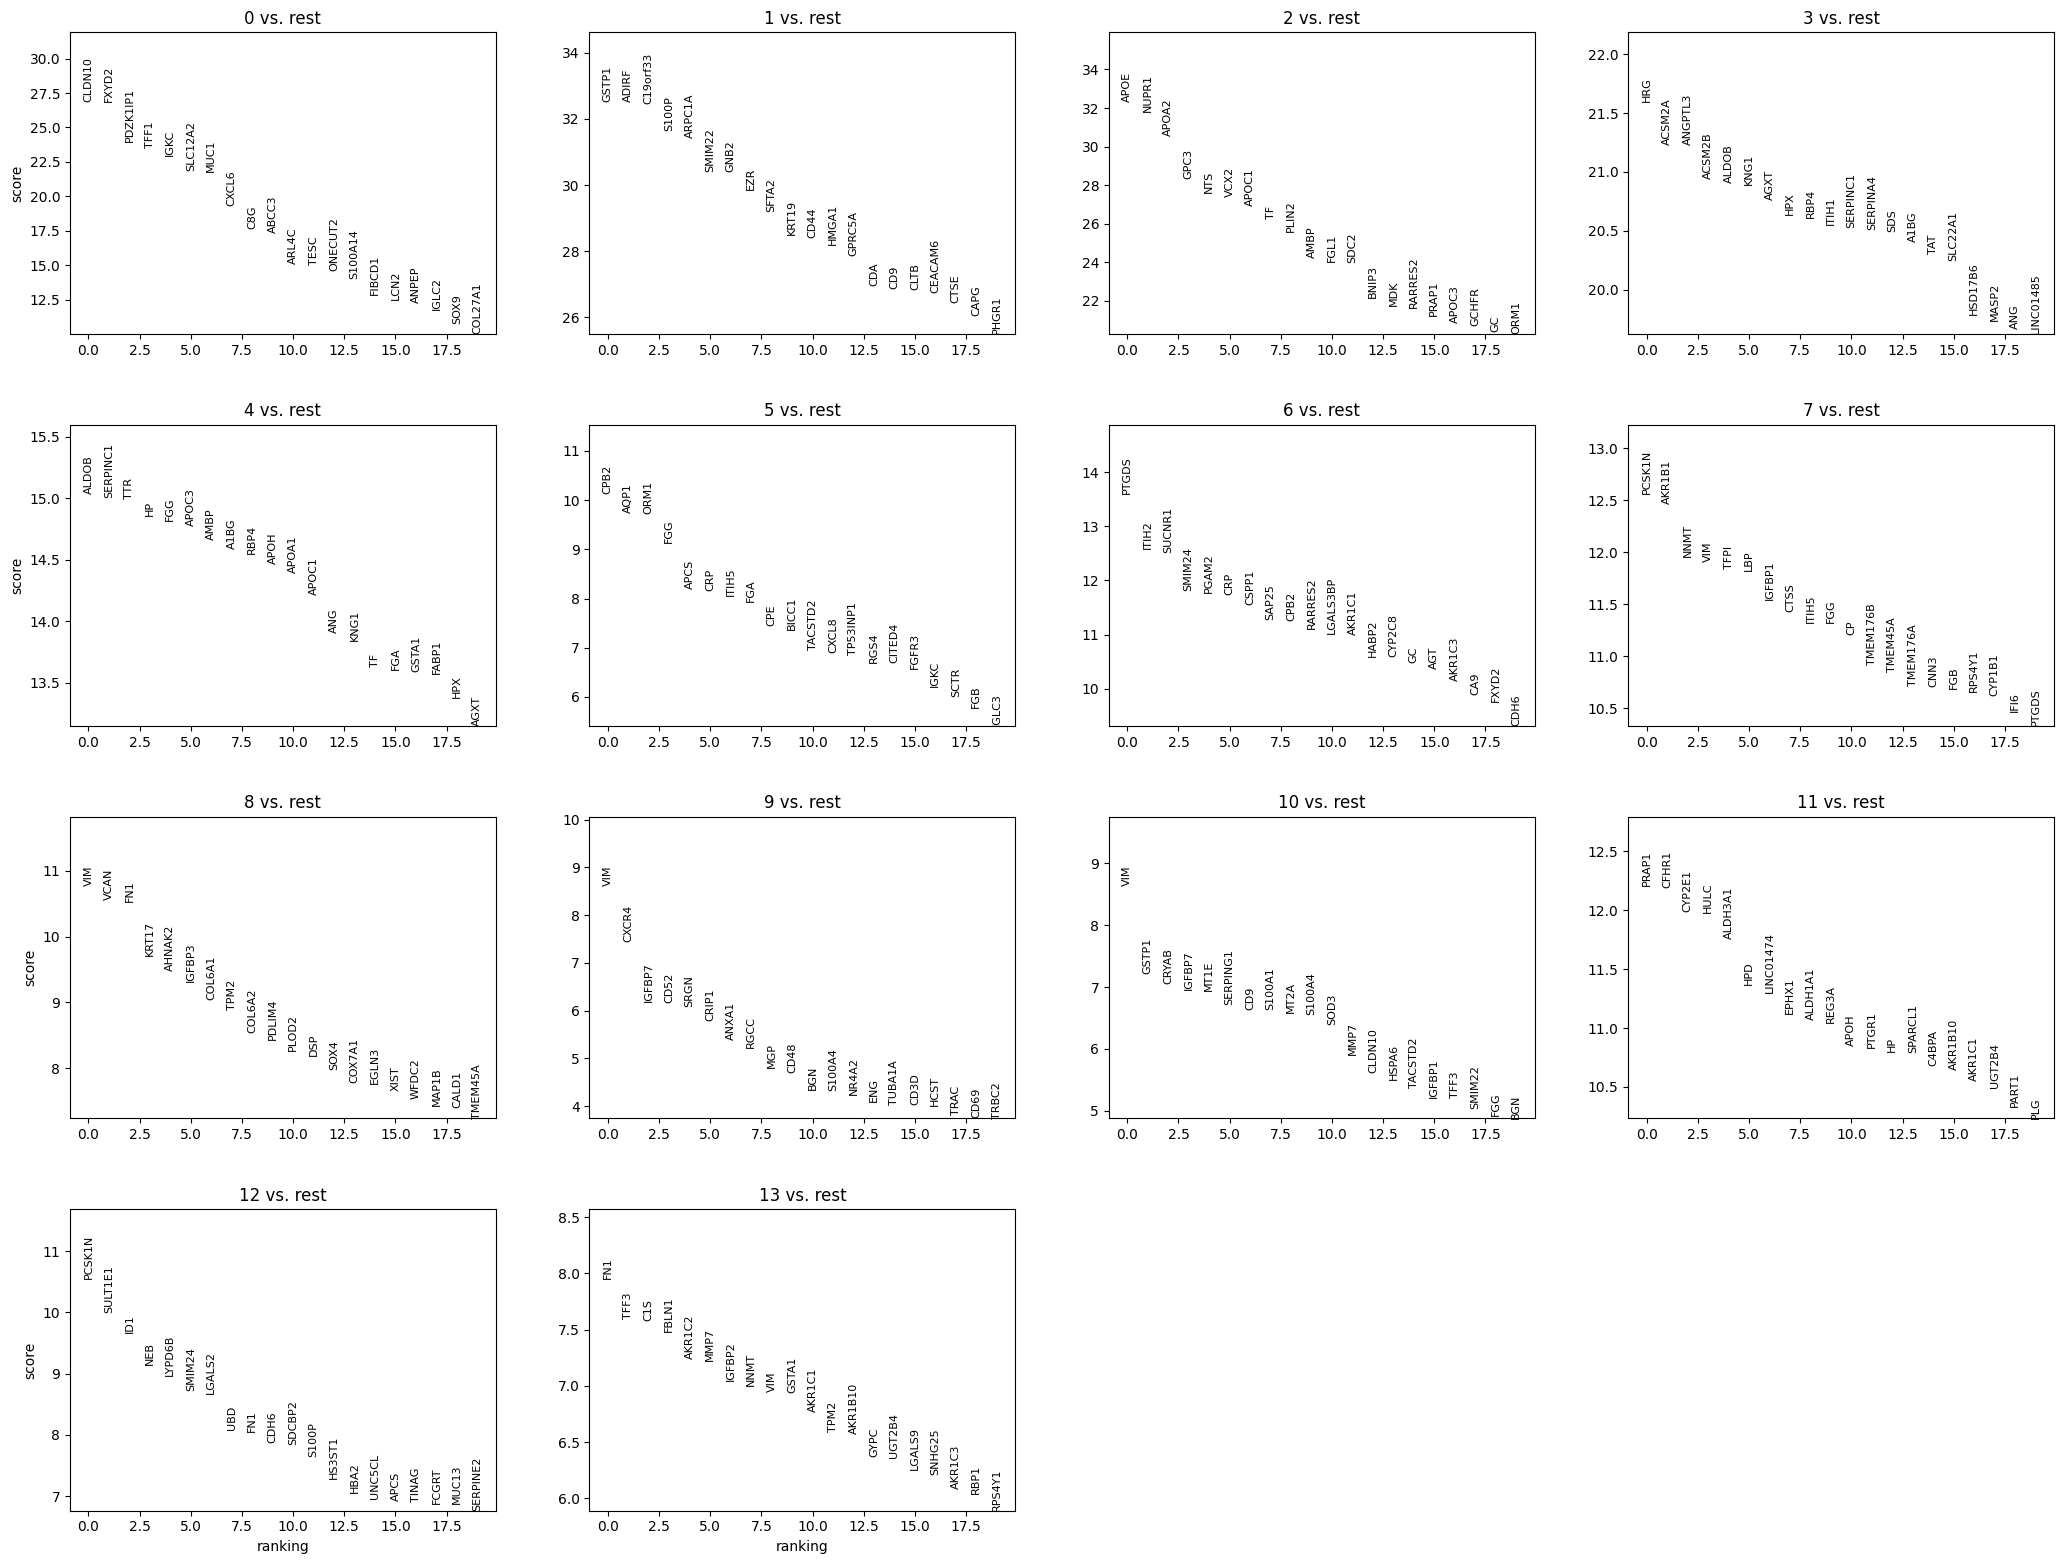

In [ ]:
sc.tl.rank_genes_groups(
    adata_tum,
    groupby="tumor_leiden",
    method="wilcoxon",
    pts=True
)

sc.pl.rank_genes_groups(adata_tum, n_genes=20, sharey=False)


*Export top markers per state:*

In [ ]:
markers_states = sc.get.rank_genes_groups_df(adata_tum, group=None)
markers_states.head(20)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CLDN10,26.855318,5.070291,7.310756e-159,1.462151e-155,0.739241,0.138049
1,0,FXYD2,26.827654,3.919609,1.537744e-158,1.537744e-155,0.803797,0.310325
2,0,PDZK1IP1,23.976570,2.977849,4.882845e-127,1.395099e-124,0.773418,0.420993
3,0,TFF1,23.525581,5.267188,2.232706e-122,5.581765e-120,0.637975,0.100970
4,0,IGKC,22.927900,3.437015,2.448658e-116,4.897315e-114,0.713924,0.316600
5,0,SLC12A2,21.837820,3.382761,1.014815e-105,1.561254e-103,0.664557,0.290359
6,0,MUC1,21.751534,3.236664,6.680958e-105,9.544225e-103,0.710127,0.312607
7,0,CXCL6,19.289547,3.931232,6.574705e-83,5.977005e-81,0.565823,0.146035
8,0,C8G,17.642290,2.124361,1.166385e-69,7.525062e-68,0.660759,0.418140
9,0,ABCC3,17.328684,2.158440,2.857988e-67,1.732114e-65,0.622785,0.429549


# Phase 7D.2 — DE: HCC vs iCCA within tumor space

First confirm disease labels present

In [ ]:
print(adata_tum.obs["disease"].value_counts())


disease
intrahepatic cholangiocarcinoma    1730
hepatocellular carcinoma            813
Name: count, dtype: int64


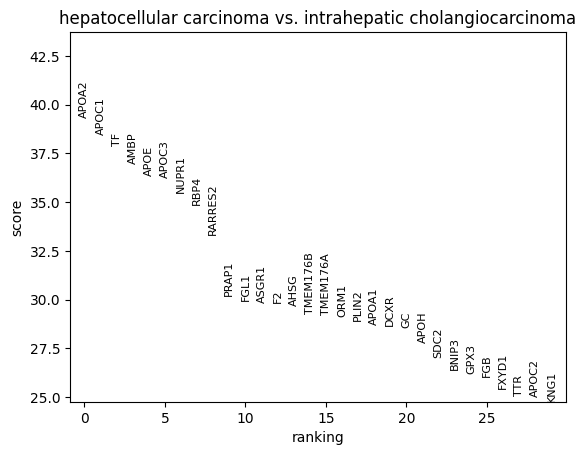

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,APOA2,39.346134,8.137376,0.000000e+00,0.000000e+00,0.980320
1,APOC1,38.437794,6.559759,0.000000e+00,0.000000e+00,0.980320
2,TF,37.915726,9.899881,0.000000e+00,0.000000e+00,0.937269
3,AMBP,36.959232,6.469400,5.177002e-299,2.588501e-296,0.974170
4,APOE,36.354839,5.952899,2.203514e-289,8.814055e-287,0.965560
5,APOC3,36.237858,9.083329,1.543546e-287,5.145152e-285,0.901599
6,NUPR1,35.503544,6.049130,4.334108e-276,1.238317e-273,0.940959
7,RBP4,34.858582,6.998275,3.155996e-266,7.889990e-264,0.894219
8,RARRES2,33.319790,5.765408,1.995858e-243,4.435240e-241,0.966790
9,PRAP1,30.197964,5.048047,2.518938e-200,5.037877e-198,0.843788


In [ ]:
# Keep only the two key groups (adjust if labels differ)
keep = adata_tum.obs["disease"].isin(["hepatocellular carcinoma", "intrahepatic cholangiocarcinoma"])
adata_tum2 = adata_tum[keep].copy()

sc.tl.rank_genes_groups(
    adata_tum2,
    groupby="disease",
    groups=["hepatocellular carcinoma"],
    reference="intrahepatic cholangiocarcinoma",
    method="wilcoxon",
    pts=True
)

sc.pl.rank_genes_groups(adata_tum2, n_genes=30, sharey=False)

de_hcc_vs_icca = sc.get.rank_genes_groups_df(adata_tum2, group="hepatocellular carcinoma")
de_hcc_vs_icca.head(30)


- Consider as within-tumor contrasts.

- If donor effects look strong, add a donor-aware pseudobulk DE next (optional, but recommended there is detected donor-skew).


# **Phase 7E — Diffusion map (optional, only if warranted)**

Trigger condition: tumor-only UMAP suggests a continuum (elongated manifold) and program scores show smooth gradients.

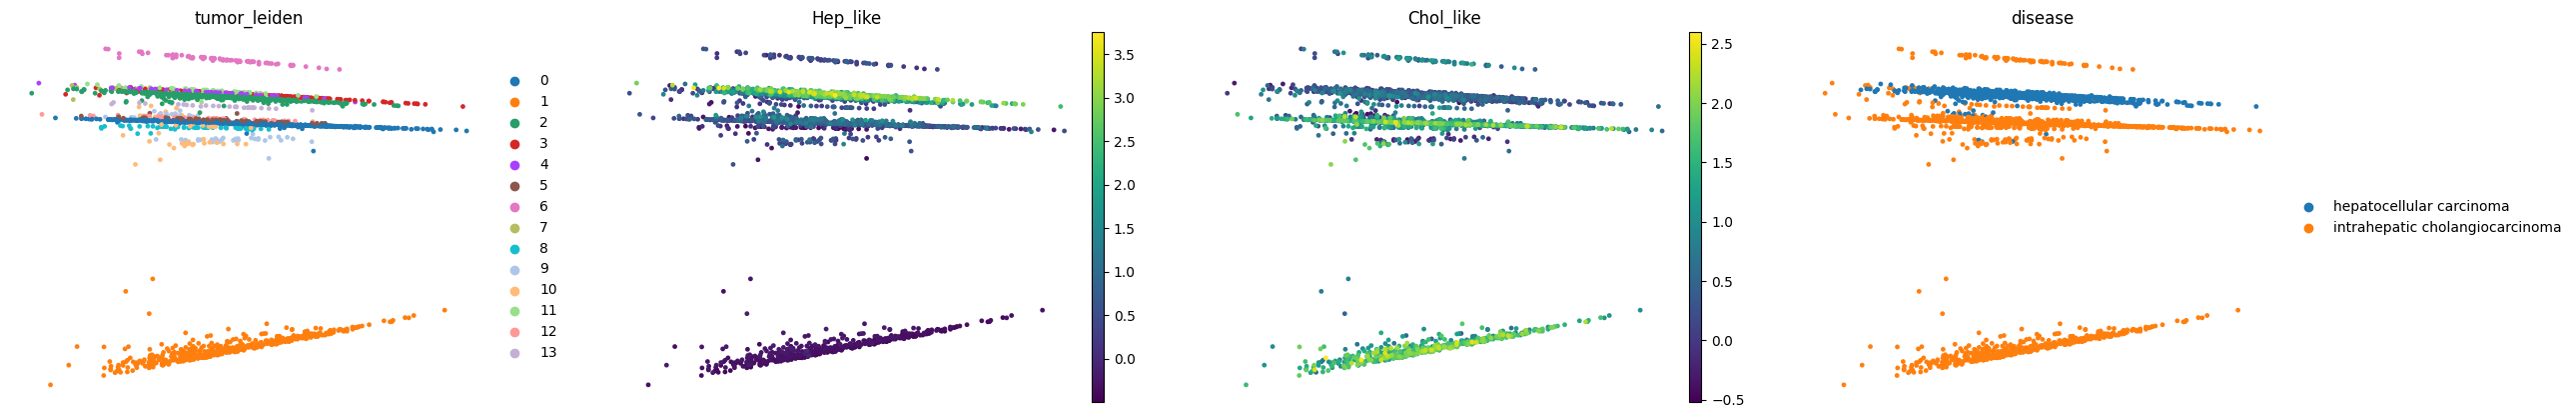

In [ ]:
sc.tl.diffmap(adata_tum)
sc.pl.embedding(adata_tum, basis="X_diffmap", color=["tumor_leiden","Hep_like","Chol_like","disease"], frameon=False)


# **Phase 8.1 — Assign biological meaning to tumor_leiden clusters**

This step is interpretive but anchored strictly to the DE PDFs (7D.1) and the lineage overlays that had been validated.

**Canonical malignant state definitions (for liver cancer)**

The step will use five tumor-intrinsic states that are standard, interpretable, and non-overlapping:



**1. Differentiated Hepatocyte-like (Hep-Diff)**

Markers: ALB, APOA1/2, APOC1/3, TTR, RBP4, CPS1, ASGR1/2

Typically enriched in HCC

**2. Differentiated Cholangiocyte-like (Chol-Diff)**

Markers: EPCAM, KRT7, KRT19, SOX9, MUC1, CEACAM6

Typically enriched in iCCA

**3. Stress / Inflammatory**

Markers: CRP, CP, FGG, FGA, ITIH genes, UBD, NUPR1

Often shared across HCC and iCCA

**4. EMT / Mesenchymal-like**

Markers: VIM, FN1, VCAN, COL1A1/2, TAGLN, TPM2, IGFBP7

Associated with invasion, plasticity

**5. Proliferative (if present)**

Markers: MKI67, TOP2A, UBE2C, CENPF

Cell-cycle driven malignant state



From DE panels:

Existing data (1), (2), (3), (4)

Proliferative appears minor or absent (we will confirm programmatically)

# **Phase 8.2 — Map tumor_leiden → tumor_state**


- Inspect top markers per cluster (already computed)

- Makes the mapping explicit

In [ ]:
markers = sc.get.rank_genes_groups_df(adata_tum, group=None)

top_markers = (
    markers.sort_values(["group", "scores"], ascending=[True, False])
           .groupby("group")
           .head(10)
)

display(top_markers)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CLDN10,26.855318,5.070291,7.310756e-159,1.462151e-155,0.739241,0.138049
1,0,FXYD2,26.827654,3.919609,1.537744e-158,1.537744e-155,0.803797,0.310325
2,0,PDZK1IP1,23.976570,2.977849,4.882845e-127,1.395099e-124,0.773418,0.420993
3,0,TFF1,23.525581,5.267188,2.232706e-122,5.581765e-120,0.637975,0.100970
4,0,IGKC,22.927900,3.437015,2.448658e-116,4.897315e-114,0.713924,0.316600
...,...,...,...,...,...,...,...,...
18005,9,CRIP1,5.784585,3.838810,7.269172e-09,8.551967e-07,0.535714,0.147969
18006,9,ANXA1,5.394431,3.515714,6.874116e-08,5.091938e-06,0.517857,0.155609
18007,9,RGCC,5.214629,5.663574,1.841859e-07,1.116278e-05,0.428571,0.032971
18008,9,MGP,4.794569,4.682158,1.630250e-06,6.792708e-05,0.410714,0.058705


# Phase 8.2.2 — Manually define the mapping (transparent & editable)

In [ ]:
# Final mapping (corrected using Phase 8.4.2 DotPlot ground truth)

tumor_state_map = {
    "0":  "Stress_Inflammatory",

    # These were previously labeled Hep_Differentiated but validated as cholangiocyte-like
    "1":  "Chol_Differentiated",
    "2":  "Chol_Differentiated",
    "7":  "Chol_Differentiated",
    "11": "Chol_Differentiated",

    # These were previously labeled Chol_Differentiated but validated as hepatocyte-like
    "3":  "Hep_Differentiated",
    "5":  "Hep_Differentiated",
    "10": "Hep_Differentiated",

    # EMT-like clusters unchanged
    "4":  "EMT_Mesenchymal",
    "8":  "EMT_Mesenchymal",
    "13": "EMT_Mesenchymal",

    # Stress-like clusters unchanged
    "6":  "Stress_Inflammatory",
    "9":  "Stress_Inflammatory",
    "12": "Stress_Inflammatory",
}

adata_tum.obs["tumor_state"] = adata_tum.obs["tumor_leiden"].astype(str).map(tumor_state_map)
adata_tum.obs["tumor_state"].value_counts()


,count
tumor_state,
Chol_Differentiated,1075
Stress_Inflammatory,964
Hep_Differentiated,313
EMT_Mesenchymal,191


In [ ]:
expected = {"Hep_Differentiated","Chol_Differentiated","EMT_Mesenchymal","Stress_Inflammatory"}
assert set(adata_tum.obs["tumor_state"].dropna().unique()).issubset(expected)


# Phase  8.2.3 — Visual validation

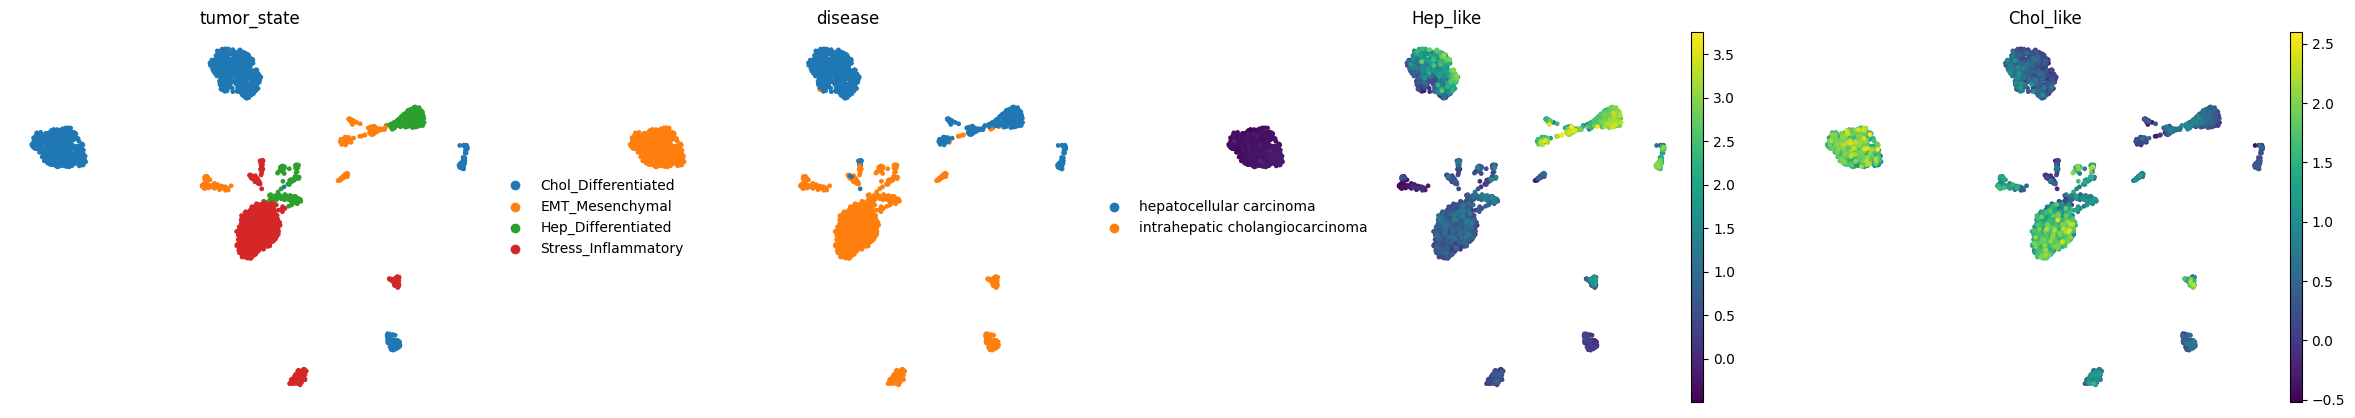

In [ ]:
sc.pl.umap(
    adata_tum,
    color=["tumor_state", "disease", "Hep_like", "Chol_like"],
    frameon=False
)


# **Phase 8.3 — Quantitative summaries**

# 8.3.1 Tumor state × disease composition

This directly answers HCC vs iCCA biology.

In [ ]:
state_disease = (
    adata_tum.obs
    .groupby(["tumor_state", "disease"])
    .size()
    .unstack(fill_value=0)
)

state_disease_pct = state_disease.div(state_disease.sum(axis=0), axis=1) * 100

display(state_disease)
display(state_disease_pct.round(1))


/tmp/ipython-input-3896200007.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tumor_state", "disease"])


disease,hepatocellular carcinoma,intrahepatic cholangiocarcinoma
tumor_state,,
Chol_Differentiated,522,553
EMT_Mesenchymal,99,92
Hep_Differentiated,178,135
Stress_Inflammatory,14,950


disease,hepatocellular carcinoma,intrahepatic cholangiocarcinoma
tumor_state,,
Chol_Differentiated,64.2,32.0
EMT_Mesenchymal,12.2,5.3
Hep_Differentiated,21.9,7.8
Stress_Inflammatory,1.7,54.9


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=state_disease)

https://docs.google.com/spreadsheets/d/1MVxOumYddon_bY4H09zKTHSZKsmcgHAfi4q6fSTnK8s/edit#gid=0


***Interpretation expectation***

1. HCC → enriched in Hep_Differentiated ± Stress

2. iCCA → enriched in Chol_Differentiated ± EMTa

# Phase 8.3.2 Tumor state × program scores

In [ ]:
programs = ["Hep_like", "Chol_like", "Tumor_lineage_score"]

state_programs = (
    adata_tum.obs
    .groupby("tumor_state")[programs]
    .mean()
)

display(state_programs)


/tmp/ipython-input-3691977798.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("tumor_state")[programs]


,Hep_like,Chol_like,Tumor_lineage_score
tumor_state,,,
Chol_Differentiated,0.502918,0.819092,1.322010
EMT_Mesenchymal,1.386498,0.454312,1.840810
Hep_Differentiated,1.805598,0.554582,2.360179
Stress_Inflammatory,0.436523,1.041124,1.477647


# **Phase 8.4 — Validate  correct tumor_state labels**

# Phase 8.4.1 — Check how many marker genes were actually used in scoring

In [ ]:
hep_markers  = ["ALB","APOA1","APOA2","TTR","RBP4","CPS1","ASGR1","ASGR2","TAT"]
chol_markers = ["KRT19","KRT7","EPCAM","SOX9","MUC1","KRT8","KRT18","CEACAM6","MMP7"]

print("Hep markers present:", [g for g in hep_markers if g in adata_tum.var_names])
print("Chol markers present:", [g for g in chol_markers if g in adata_tum.var_names])


Hep markers present: ['APOA1', 'APOA2', 'TTR', 'RBP4', 'CPS1', 'ASGR1', 'ASGR2', 'TAT']
Chol markers present: ['KRT19', 'KRT7', 'EPCAM', 'SOX9', 'MUC1', 'CEACAM6', 'MMP7']


# Phase 8.4.2 — DotPlot (ground truth check)

For labeling validation

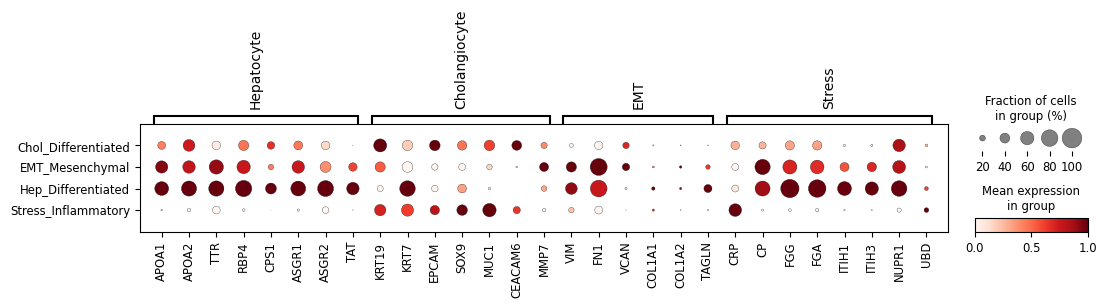

In [ ]:
import scanpy as sc

# Filter marker lists to include only genes present in adata_tum.var_names
hep_markers_present  = [g for g in hep_markers if g in adata_tum.var_names]
chol_markers_present = [g for g in chol_markers if g in adata_tum.var_names]
emt_markers = ["VIM","FN1","VCAN","COL1A1","COL1A2","TAGLN"]
stress_markers = ["CRP","CP","FGG","FGA","ITIH1","ITIH3","NUPR1","UBD"]

# Filter EMT and Stress markers as well to avoid future errors if they are not present
emt_markers_present = [g for g in emt_markers if g in adata_tum.var_names]
stress_markers_present = [g for g in stress_markers if g in adata_tum.var_names]


sc.pl.dotplot(
    adata_tum,
    var_names={
        "Hepatocyte": hep_markers_present,
        "Cholangiocyte": chol_markers_present,
        "EMT": emt_markers_present,
        "Stress": stress_markers_present
    },
    groupby="tumor_state",
    standard_scale="var",
    dendrogram=False
)

In [ ]:
state_rename = {
    "Chol_Differentiated": "Hep_Differentiated",
    "Hep_Differentiated": "Chol_Differentiated"
}

adata_tum.obs["tumor_state_corrected"] = (
    adata_tum.obs["tumor_state"].replace(state_rename)
)

adata_tum.obs["tumor_state_corrected"].value_counts()


,count
tumor_state_corrected,
Hep_Differentiated,1075
Stress_Inflammatory,964
Chol_Differentiated,313
EMT_Mesenchymal,191


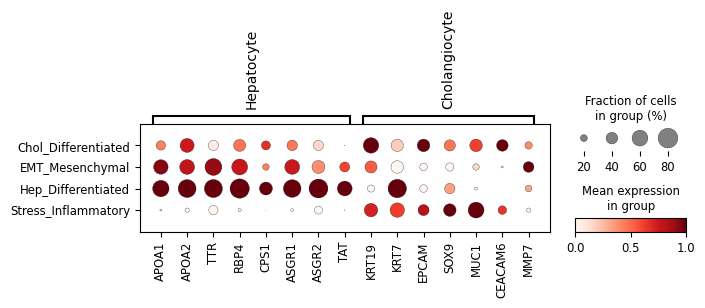

In [ ]:
sc.pl.dotplot(
    adata_tum,
    var_names={
        "Hepatocyte": ["APOA1","APOA2","TTR","RBP4","CPS1","ASGR1","ASGR2","TAT"],
        "Cholangiocyte": ["KRT19","KRT7","EPCAM","SOX9","MUC1","CEACAM6","MMP7"],
    },
    groupby="tumor_state",
    standard_scale="var",
    dendrogram=False
)


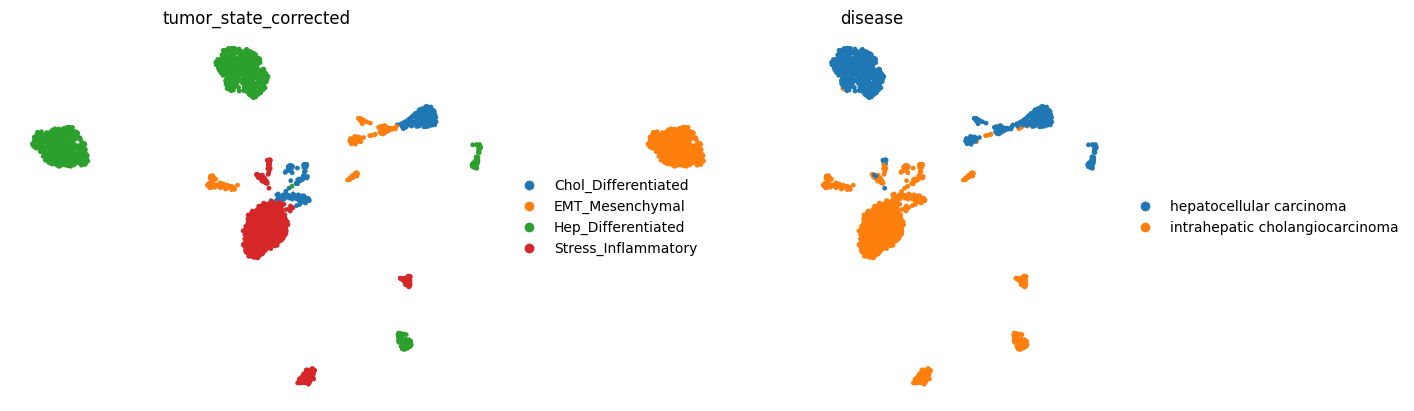

In [ ]:
sc.pl.umap(
    adata_tum,
    color=["tumor_state_corrected", "disease"],
    frameon=False
)


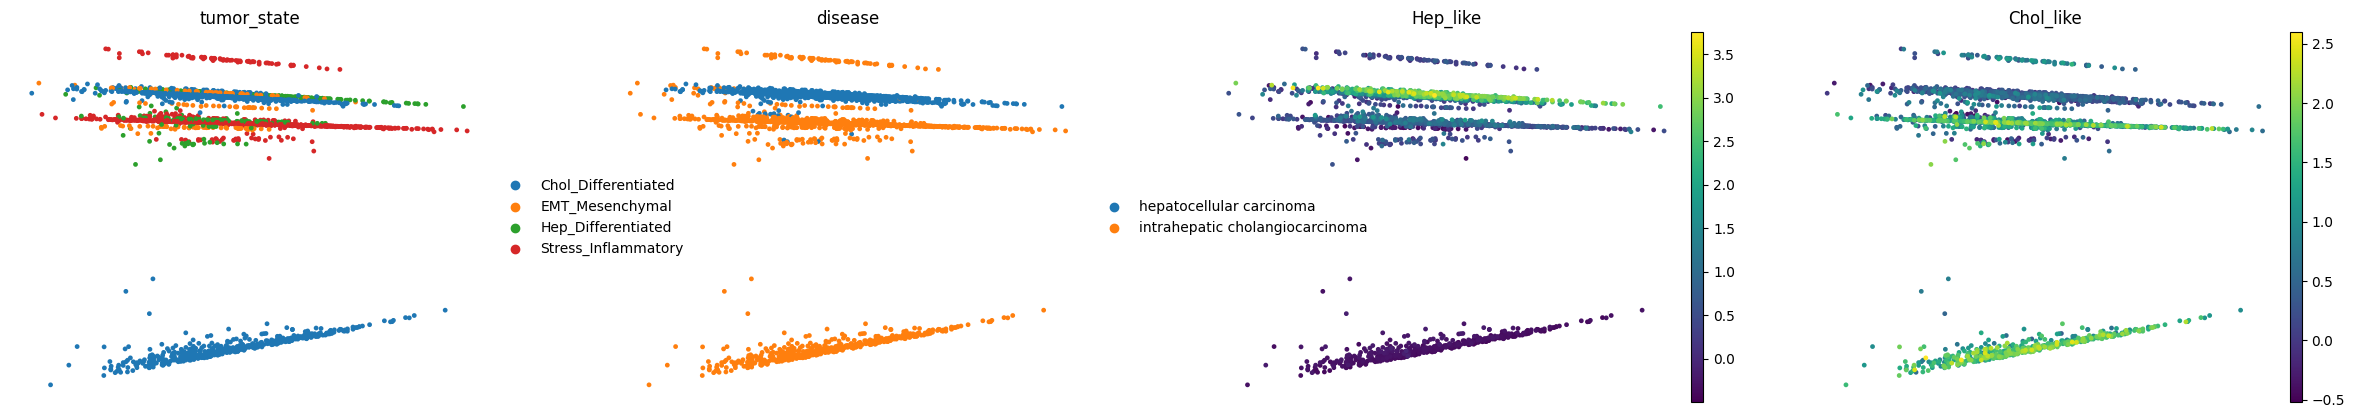

In [ ]:
import scanpy as sc

# Assumes neighbors graph exists on adata_tum
# If not, uncomment:
# sc.pp.neighbors(adata_tum, n_neighbors=15, n_pcs=50)

sc.tl.diffmap(adata_tum)

# Visualize diffusion components (usually DC1 vs DC2)
sc.pl.embedding(
    adata_tum,
    basis="X_diffmap",
    color=["tumor_state", "disease", "Hep_like", "Chol_like"],
    frameon=False
)


**D. Summary**



This project demonstrates a robust and iterative workflow for analyzing single-cell RNA-seq data from human liver cancer. By systematically progressing through data acquisition, stringent quality control, and sophisticated bioinformatic analyses using `Scanpy`, we successfully identified distinct tumor-intrinsic states within a chosen dataset comprising Hepatocellular Carcinoma (HCC) and Intrahepatic Cholangiocarcinoma (iCCA) cells.

The process involved careful selection of a relevant dataset from the Cellxgene Census, followed by standard preprocessing techniques. A key aspect of the workflow was the rigorous identification and purification of tumor-like cells, leveraging both general cell type markers and specific biological program scores. This iterative refinement, including the removal of suspect non-tumor clusters and re-embedding of tumor-only cells, was crucial for resolving fine-grained tumor heterogeneity.

Differential expression analysis provided molecular insights into the distinguishing features of each identified tumor state and the differences between HCC and iCCA at a single-cell level. Finally, clusters were assigned to biologically meaningful tumor states, which were then validated through quantitative summaries and visual confirmation using canonical marker genes via DotPlots and UMAPs. This comprehensive approach ensures that the identified tumor states are well-supported by their transcriptional profiles and their distribution across disease types.

The findings, including the compositional differences of tumor states between HCC and iCCA and their correlation with specific biological programs, provide a foundation for understanding the complex cellular landscape of liver cancer. The iterative nature of the analysis, particularly the correction of tumor state labels based on ground truth checks, highlights the importance of combining computational methods with expert biological interpretation to derive reliable and meaningful conclusions from single-cell data.